# Maintenance Service Events Prediction Modeling of Aircraft Gas Turbine Engines
## PHM North America 2025 Data Challenge — Paper Implementation

This notebook implements the methodology from the MathWorks paper:
*"Maintenance Service Events Prediction Modeling of Aircraft Gas Turbine Engines"*
by Peeyush Pankaj, Shyam Joshi, Xiaomeng Peng, Reece Teramoto, Taylor Hearn.

**Problem:** Multi-event RUL estimation for AGTF30 aircraft gas turbine engine modules.
Three maintenance events to predict simultaneously:
- **HPC SV** — High Pressure Compressor shop visits
- **HPT SV** — High Pressure Turbine shop visits  
- **WW** — Water Wash events

### Workflow:
1. Data Loading & Exploration
2. Preprocessing (missing data, outliers)
3. Virtual Sensor Modeling (P25, T5)
4. Snapshot Aggregation to Cycle-level
5. Feature Engineering (pressure ratios, temp drops, efficiencies)
6. Health Indicator Design
7. Model Training (ANN for HPT, LSTM for WW & HPC)
8. Profile Registration for Test/Validation
9. Prediction & Submission Generation

In [61]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Paths
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
DATA_DIR = os.path.join(BASE_DIR, 'Data')
TRAIN_PATH = os.path.join(DATA_DIR, 'PHM2025_training_data', 'training_data.csv')
TEST_DIR = os.path.join(DATA_DIR, 'PHM2025_test_data')
VAL_DIR = os.path.join(DATA_DIR, 'PHM2025_validation_data')
EVENTS_DIR = os.path.join(DATA_DIR, 'EVENTS')

print(f'Base dir: {BASE_DIR}')
print(f'Training file exists: {os.path.exists(TRAIN_PATH)}')
print(f'Test files: {len(glob.glob(os.path.join(TEST_DIR, "test_*.csv")))}')
print(f'Val files: {len(glob.glob(os.path.join(VAL_DIR, "val_*.csv")))}')

Using device: cuda
Base dir: /home/began/srcs/begbaj/phm-america-2025
Training file exists: True
Test files: 52
Val files: 48


---
## 1. Data Loading & Exploration

Training data: 4 ESNs (101-104), each ~20,000 cycles, up to 8 snapshots per cycle.
16 primary sensors covering pressures, temperatures, rotor speeds, actuator positions.
Labels: cumulative event counters + remaining cycles to next event.

In [62]:
# Load training data
df_train = pd.read_csv(TRAIN_PATH)
print(f'Training data shape: {df_train.shape}')
print(f'Columns: {list(df_train.columns)}')
df_train.head()

Training data shape: (59702, 25)
Columns: ['ESN', 'Cycles_Since_New', 'Snapshot', 'Cumulative_WWs', 'Cumulative_HPC_SVs', 'Cumulative_HPT_SVs', 'Sensed_Altitude', 'Sensed_Mach', 'Sensed_Pamb', 'Sensed_Pt2', 'Sensed_TAT', 'Sensed_WFuel', 'Sensed_VAFN', 'Sensed_VBV', 'Sensed_Fan_Speed', 'Sensed_Core_Speed', 'Sensed_T25', 'Sensed_T3', 'Sensed_Ps3', 'Sensed_T45', 'Sensed_P25', 'Sensed_T5', 'Cycles_to_WW', 'Cycles_to_HPC_SV', 'Cycles_to_HPT_SV']


,ESN,Cycles_Since_New,Snapshot,Cumulative_WWs,Cumulative_HPC_SVs,Cumulative_HPT_SVs,Sensed_Altitude,Sensed_Mach,Sensed_Pamb,Sensed_Pt2,...,Sensed_Core_Speed,Sensed_T25,Sensed_T3,Sensed_Ps3,Sensed_T45,Sensed_P25,Sensed_T5,Cycles_to_WW,Cycles_to_HPC_SV,Cycles_to_HPT_SV
0,101,0,1,0,0,0,851.321516,0.103224,14.250475,14.289459,...,21261.365607,744.009196,1609.417021,474.158862,2173.316575,40.065810,1415.477470,910,8510,4090
1,101,0,2,0,0,0,903.321516,0.213663,14.224853,14.628042,...,21280.040466,747.318490,1612.148051,483.190299,2172.105766,41.152081,1409.643967,910,8510,4090
2,101,0,3,0,0,0,3410.321516,0.345333,12.989563,14.055733,...,21014.282876,735.730180,1576.031353,442.421527,2106.463686,38.758249,1365.412495,910,8510,4090
3,101,0,4,0,0,0,20259.321516,0.619005,6.679796,8.621275,...,20466.466115,706.293618,1504.811122,283.988928,2016.969960,25.574967,1256.689540,910,8510,4090
4,101,0,6,0,0,0,21991.321516,0.640425,6.230955,8.183755,...,20313.501657,699.650483,1484.629857,261.543915,1984.370026,23.927579,1238.665408,910,8510,4090


In [63]:
# Sensor columns (the 16 primary sensors)
SENSOR_COLS = [
    'Sensed_Altitude', 'Sensed_Mach', 'Sensed_Pamb', 'Sensed_Pt2',
    'Sensed_TAT', 'Sensed_WFuel', 'Sensed_VAFN', 'Sensed_VBV',
    'Sensed_Fan_Speed', 'Sensed_Core_Speed', 'Sensed_T25', 'Sensed_T3',
    'Sensed_Ps3', 'Sensed_T45', 'Sensed_P25', 'Sensed_T5'
]

TARGET_COLS = ['Cycles_to_WW', 'Cycles_to_HPC_SV', 'Cycles_to_HPT_SV']
META_COLS = ['ESN', 'Cycles_Since_New', 'Snapshot', 'Cumulative_WWs', 'Cumulative_HPC_SVs', 'Cumulative_HPT_SVs']

# Basic stats
print('=== Data Distribution per ESN ===')
for esn in sorted(df_train.ESN.unique()):
    sub = df_train[df_train.ESN == esn]
    print(f'ESN {esn}: {sub.Cycles_Since_New.nunique()} unique cycles, '
          f'{len(sub)} rows, cycles {sub.Cycles_Since_New.min()}-{sub.Cycles_Since_New.max()}')

print(f'\nMissing values:\n{df_train[SENSOR_COLS].isnull().sum()}')

=== Data Distribution per ESN ===
ESN 101: 2001 unique cycles, 14738 rows, cycles 0-20000
ESN 102: 2001 unique cycles, 15044 rows, cycles 0-20000
ESN 103: 2001 unique cycles, 14856 rows, cycles 0-20000
ESN 104: 2001 unique cycles, 15064 rows, cycles 0-20000

Missing values:
Sensed_Altitude        0
Sensed_Mach            0
Sensed_Pamb            0
Sensed_Pt2             0
Sensed_TAT             0
Sensed_WFuel         697
Sensed_VAFN            0
Sensed_VBV             0
Sensed_Fan_Speed       0
Sensed_Core_Speed    697
Sensed_T25             0
Sensed_T3             60
Sensed_Ps3            60
Sensed_T45           757
Sensed_P25             0
Sensed_T5            757
dtype: int64


In [64]:
# Load event files
events = {}
for event_type in ['hpc', 'hpt', 'wws']:
    events[event_type] = {}
    for esn in [101, 102, 103, 104]:
        fname = os.path.join(EVENTS_DIR, f'{event_type}_{esn}.csv')
        if os.path.exists(fname):
            events[event_type][esn] = pd.read_csv(fname)

print('=== Event Counts per ESN ===')
for event_type in ['hpc', 'hpt', 'wws']:
    for esn in [101, 102, 103, 104]:
        ev = events[event_type][esn]
        print(f'{event_type.upper()} ESN {esn}: {len(ev)} events at cycles {list(ev.Cycles_Since_New)}')

=== Event Counts per ESN ===
HPC ESN 101: 2 events at cycles [8520, 15930]
HPC ESN 102: 2 events at cycles [9010, 17640]
HPC ESN 103: 2 events at cycles [7460, 14510]
HPC ESN 104: 2 events at cycles [9540, 18260]
HPT ESN 101: 5 events at cycles [4100, 8020, 11460, 14880, 17710]
HPT ESN 102: 6 events at cycles [3860, 7400, 10760, 13630, 16210, 18500]
HPT ESN 103: 5 events at cycles [4800, 9190, 12860, 16140, 18900]
HPT ESN 104: 6 events at cycles [3980, 7530, 11040, 14070, 16880, 19410]
WWS ESN 101: 20 events at cycles [920, 1820, 2940, 3970, 4910, 5780, 6770, 7780, 8850, 9880, 10760, 11820, 12870, 13760, 14670, 15830, 16870, 17910, 18900, 19860]
WWS ESN 102: 19 events at cycles [1090, 2160, 3080, 4100, 5160, 6200, 7280, 8160, 9140, 10040, 10970, 11990, 13160, 13990, 15030, 16090, 17010, 18090, 19060]
WWS ESN 103: 20 events at cycles [1030, 2140, 3140, 4070, 5090, 6160, 7100, 8090, 9050, 10120, 11250, 12230, 13230, 14140, 15060, 16070, 16940, 17990, 19040, 19990]
WWS ESN 104: 20 events 

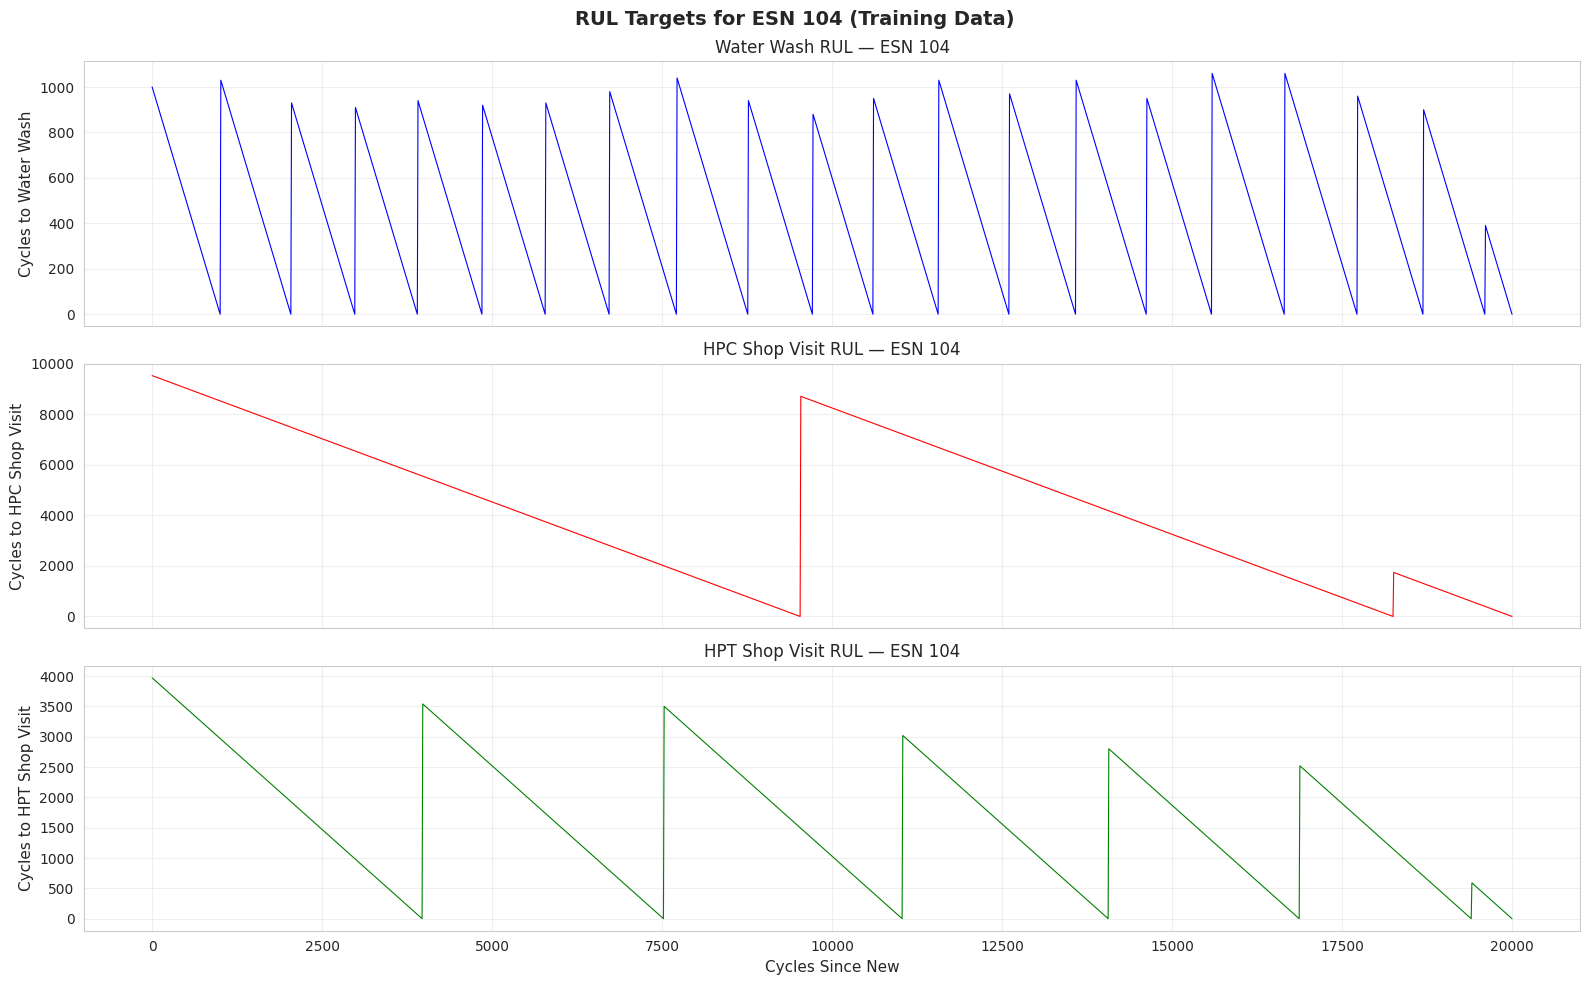

In [65]:
# Figure 2: RUL for 3 events on training data (ESN 104 shown as example)
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

esn_show = 104
sub = df_train[(df_train.ESN == esn_show) & (df_train.Snapshot == 1)].sort_values('Cycles_Since_New')

for i, (target, color, label) in enumerate([
    ('Cycles_to_WW', 'blue', 'Water Wash'),
    ('Cycles_to_HPC_SV', 'red', 'HPC Shop Visit'),
    ('Cycles_to_HPT_SV', 'green', 'HPT Shop Visit')
]):
    axes[i].plot(sub['Cycles_Since_New'], sub[target], color=color, linewidth=0.8)
    axes[i].set_ylabel(f'Cycles to {label}', fontsize=11)
    axes[i].set_title(f'{label} RUL — ESN {esn_show}', fontsize=12)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Cycles Since New', fontsize=11)
plt.suptitle(f'RUL Targets for ESN {esn_show} (Training Data)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

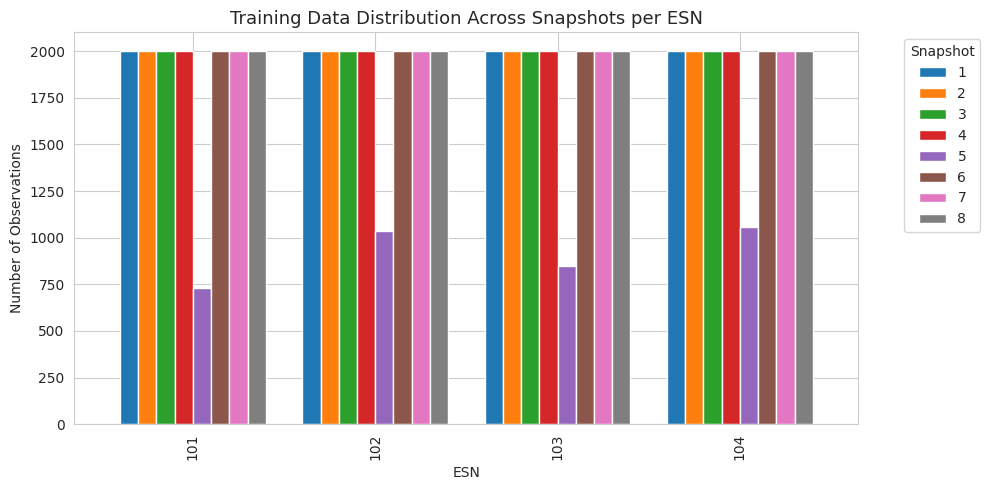

Snapshot counts (total across ESNs):
Snapshot
1    8004
2    8004
3    8004
4    8004
5    3674
6    8004
7    8004
8    8004
Name: count, dtype: int64


In [66]:
# Figure 3: Training data distribution across snapshots
fig, ax = plt.subplots(figsize=(10, 5))
snapshot_counts = df_train.groupby(['ESN', 'Snapshot']).size().unstack(fill_value=0)
snapshot_counts.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Training Data Distribution Across Snapshots per ESN', fontsize=13)
ax.set_xlabel('ESN')
ax.set_ylabel('Number of Observations')
ax.legend(title='Snapshot', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('Snapshot counts (total across ESNs):')
print(df_train.Snapshot.value_counts().sort_index())

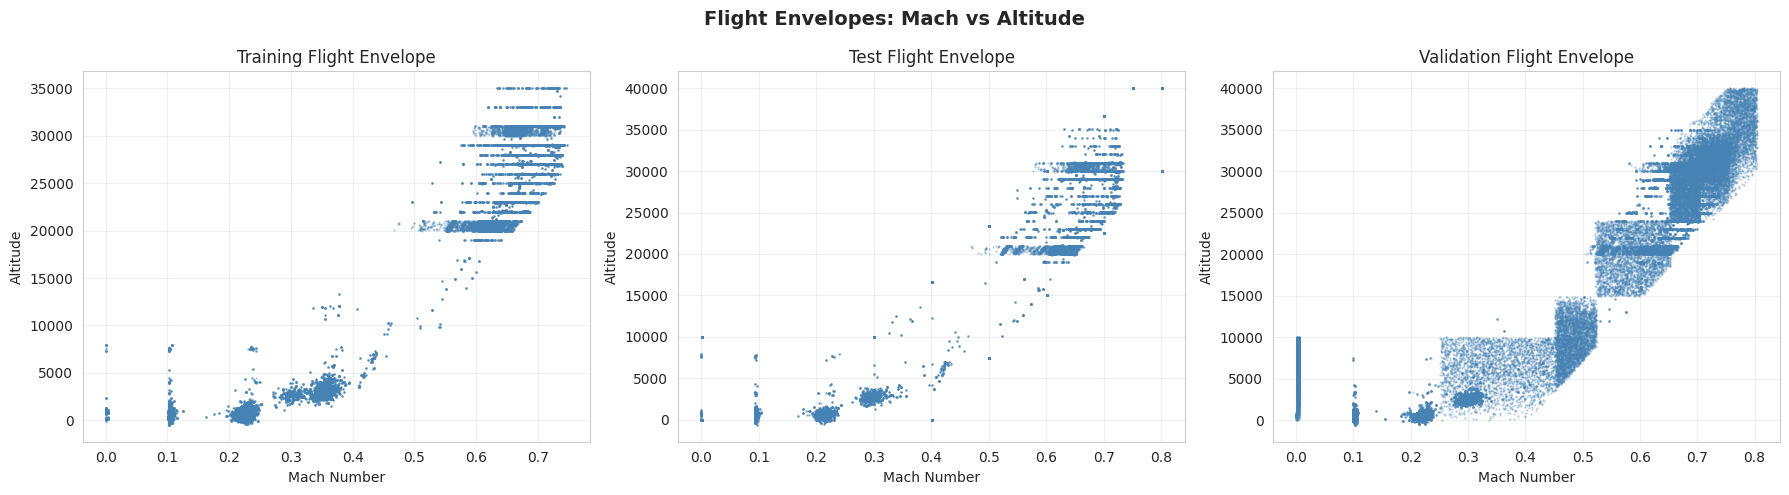

In [67]:
# Figure 4: Flight envelopes (Mach vs Altitude)
# Load test and validation data for comparison
test_files = sorted(glob.glob(os.path.join(TEST_DIR, 'test_*.csv')))
val_files = sorted(glob.glob(os.path.join(VAL_DIR, 'val_*.csv')))

df_test_all = pd.concat([pd.read_csv(f) for f in test_files], ignore_index=True)
df_val_all = pd.concat([pd.read_csv(f) for f in val_files], ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (data, title) in zip(axes, [
    (df_train, 'Training'),
    (df_test_all, 'Test'),
    (df_val_all, 'Validation')
]):
    ax.scatter(data['Sensed_Mach'], data['Sensed_Altitude'], 
              s=0.5, alpha=0.3, c='steelblue')
    ax.set_xlabel('Mach Number')
    ax.set_ylabel('Altitude')
    ax.set_title(f'{title} Flight Envelope')
    ax.grid(True, alpha=0.3)

plt.suptitle('Flight Envelopes: Mach vs Altitude', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2. Preprocessing

Steps from the paper:
1. **Duplicate removal** — check for repeated sensor values
2. **Missing data interpolation** — snapshot-wise interpolation per ESN
3. **Outlier treatment** — per-snapshot, per-ESN, using 1.5×IQR rule

In [68]:
# Step 1: Duplicate removal
print(f'Rows before duplicate check: {len(df_train)}')
dupes = df_train.duplicated(subset=SENSOR_COLS, keep='first')
print(f'Duplicate sensor rows found: {dupes.sum()}')
# Keep all rows but flag duplicates — in the paper they checked but did not find many

# Step 2: Missing data — snapshot-wise interpolation per ESN
print(f'\nMissing values BEFORE interpolation:')
print(df_train[SENSOR_COLS].isnull().sum())

df_clean = df_train.copy()
for esn in df_clean.ESN.unique():
    for snap in df_clean.Snapshot.unique():
        mask = (df_clean.ESN == esn) & (df_clean.Snapshot == snap)
        if mask.sum() > 0:
            idx_sorted = df_clean.loc[mask].sort_values('Cycles_Since_New').index
            df_clean.loc[idx_sorted, SENSOR_COLS] = (
                df_clean.loc[idx_sorted, SENSOR_COLS]
                .interpolate(method='linear', limit_direction='both')
            )

# For any remaining NaN (edge cases), use forward/backward fill
for esn in df_clean.ESN.unique():
    for snap in df_clean.Snapshot.unique():
        mask = (df_clean.ESN == esn) & (df_clean.Snapshot == snap)
        df_clean.loc[mask, SENSOR_COLS] = (
            df_clean.loc[mask, SENSOR_COLS].ffill().bfill()
        )

print(f'\nMissing values AFTER interpolation:')
print(df_clean[SENSOR_COLS].isnull().sum())

Rows before duplicate check: 59702
Duplicate sensor rows found: 4

Missing values BEFORE interpolation:
Sensed_Altitude        0
Sensed_Mach            0
Sensed_Pamb            0
Sensed_Pt2             0
Sensed_TAT             0
Sensed_WFuel         697
Sensed_VAFN            0
Sensed_VBV             0
Sensed_Fan_Speed       0
Sensed_Core_Speed    697
Sensed_T25             0
Sensed_T3             60
Sensed_Ps3            60
Sensed_T45           757
Sensed_P25             0
Sensed_T5            757
dtype: int64

Missing values AFTER interpolation:
Sensed_Altitude      0
Sensed_Mach          0
Sensed_Pamb          0
Sensed_Pt2           0
Sensed_TAT           0
Sensed_WFuel         0
Sensed_VAFN          0
Sensed_VBV           0
Sensed_Fan_Speed     0
Sensed_Core_Speed    0
Sensed_T25           0
Sensed_T3            0
Sensed_Ps3           0
Sensed_T45           0
Sensed_P25           0
Sensed_T5            0
dtype: int64


In [69]:
# Step 3: Outlier treatment — per-snapshot, per-ESN, 1.5×IQR rule
# Store before for comparison plotting
df_before_outlier = df_clean.copy()

outlier_count = 0
for esn in df_clean.ESN.unique():
    for snap in df_clean.Snapshot.unique():
        mask = (df_clean.ESN == esn) & (df_clean.Snapshot == snap)
        subset = df_clean.loc[mask, SENSOR_COLS]
        if len(subset) < 10:
            continue
        
        Q1 = subset.quantile(0.25)
        Q3 = subset.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        # Replace outliers with NaN, then interpolate
        outlier_mask = (subset < lower) | (subset > upper)
        n_outliers = outlier_mask.sum().sum()
        outlier_count += n_outliers
        
        df_clean.loc[mask, SENSOR_COLS] = subset.where(~outlier_mask, np.nan)

print(f'Total outlier values replaced: {outlier_count}')

# Re-interpolate after outlier removal
for esn in df_clean.ESN.unique():
    for snap in df_clean.Snapshot.unique():
        mask = (df_clean.ESN == esn) & (df_clean.Snapshot == snap)
        idx = df_clean.loc[mask].sort_values('Cycles_Since_New').index
        df_clean.loc[idx, SENSOR_COLS] = (
            df_clean.loc[idx, SENSOR_COLS]
            .interpolate(method='linear', limit_direction='both')
            .ffill().bfill()
        )

print(f'Missing after outlier treatment: {df_clean[SENSOR_COLS].isnull().sum().sum()}')

Total outlier values replaced: 27589
Missing after outlier treatment: 0


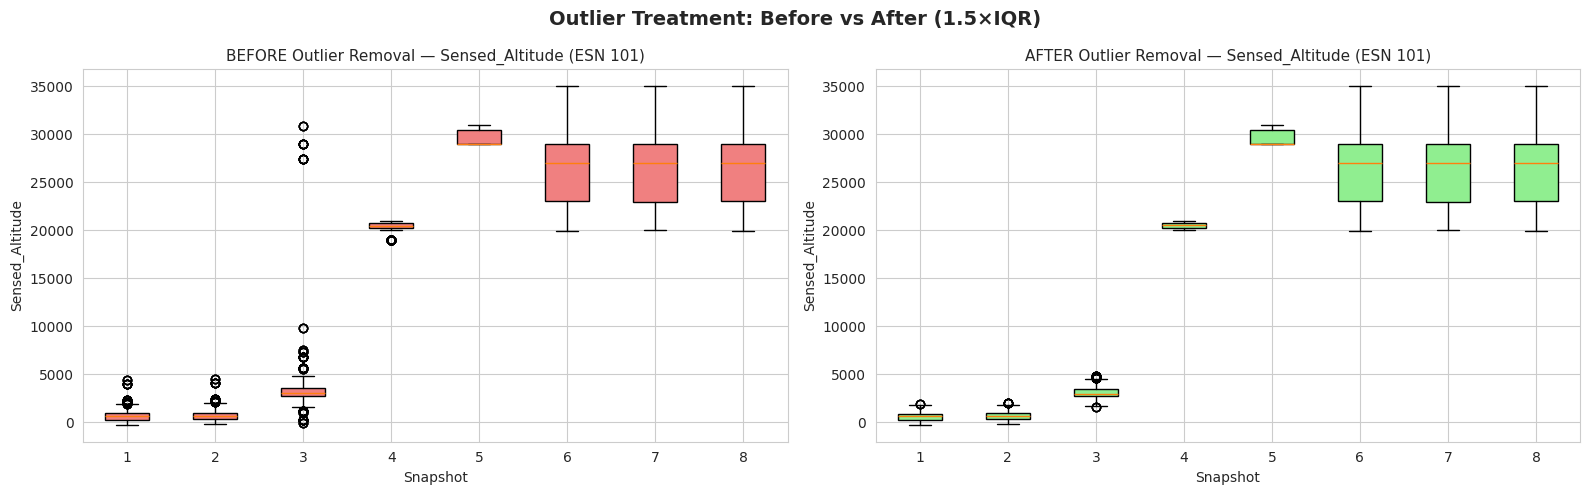

In [70]:
# Figure 5: Boxplots before/after outlier treatment (Altitude sensor shown)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sensor_to_plot = 'Sensed_Altitude'
esn_show = 101

before_data = df_before_outlier[df_before_outlier.ESN == esn_show]
after_data = df_clean[df_clean.ESN == esn_show]

# Group by snapshot for boxplots
bp1 = axes[0].boxplot([before_data[before_data.Snapshot == s][sensor_to_plot].dropna().values 
                       for s in range(1, 9)], labels=range(1, 9), patch_artist=True)
axes[0].set_title(f'BEFORE Outlier Removal — {sensor_to_plot} (ESN {esn_show})', fontsize=11)
axes[0].set_xlabel('Snapshot')
axes[0].set_ylabel(sensor_to_plot)
for patch in bp1['boxes']:
    patch.set_facecolor('lightcoral')

bp2 = axes[1].boxplot([after_data[after_data.Snapshot == s][sensor_to_plot].dropna().values 
                       for s in range(1, 9)], labels=range(1, 9), patch_artist=True)
axes[1].set_title(f'AFTER Outlier Removal — {sensor_to_plot} (ESN {esn_show})', fontsize=11)
axes[1].set_xlabel('Snapshot')
axes[1].set_ylabel(sensor_to_plot)
for patch in bp2['boxes']:
    patch.set_facecolor('lightgreen')

plt.suptitle('Outlier Treatment: Before vs After (1.5×IQR)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

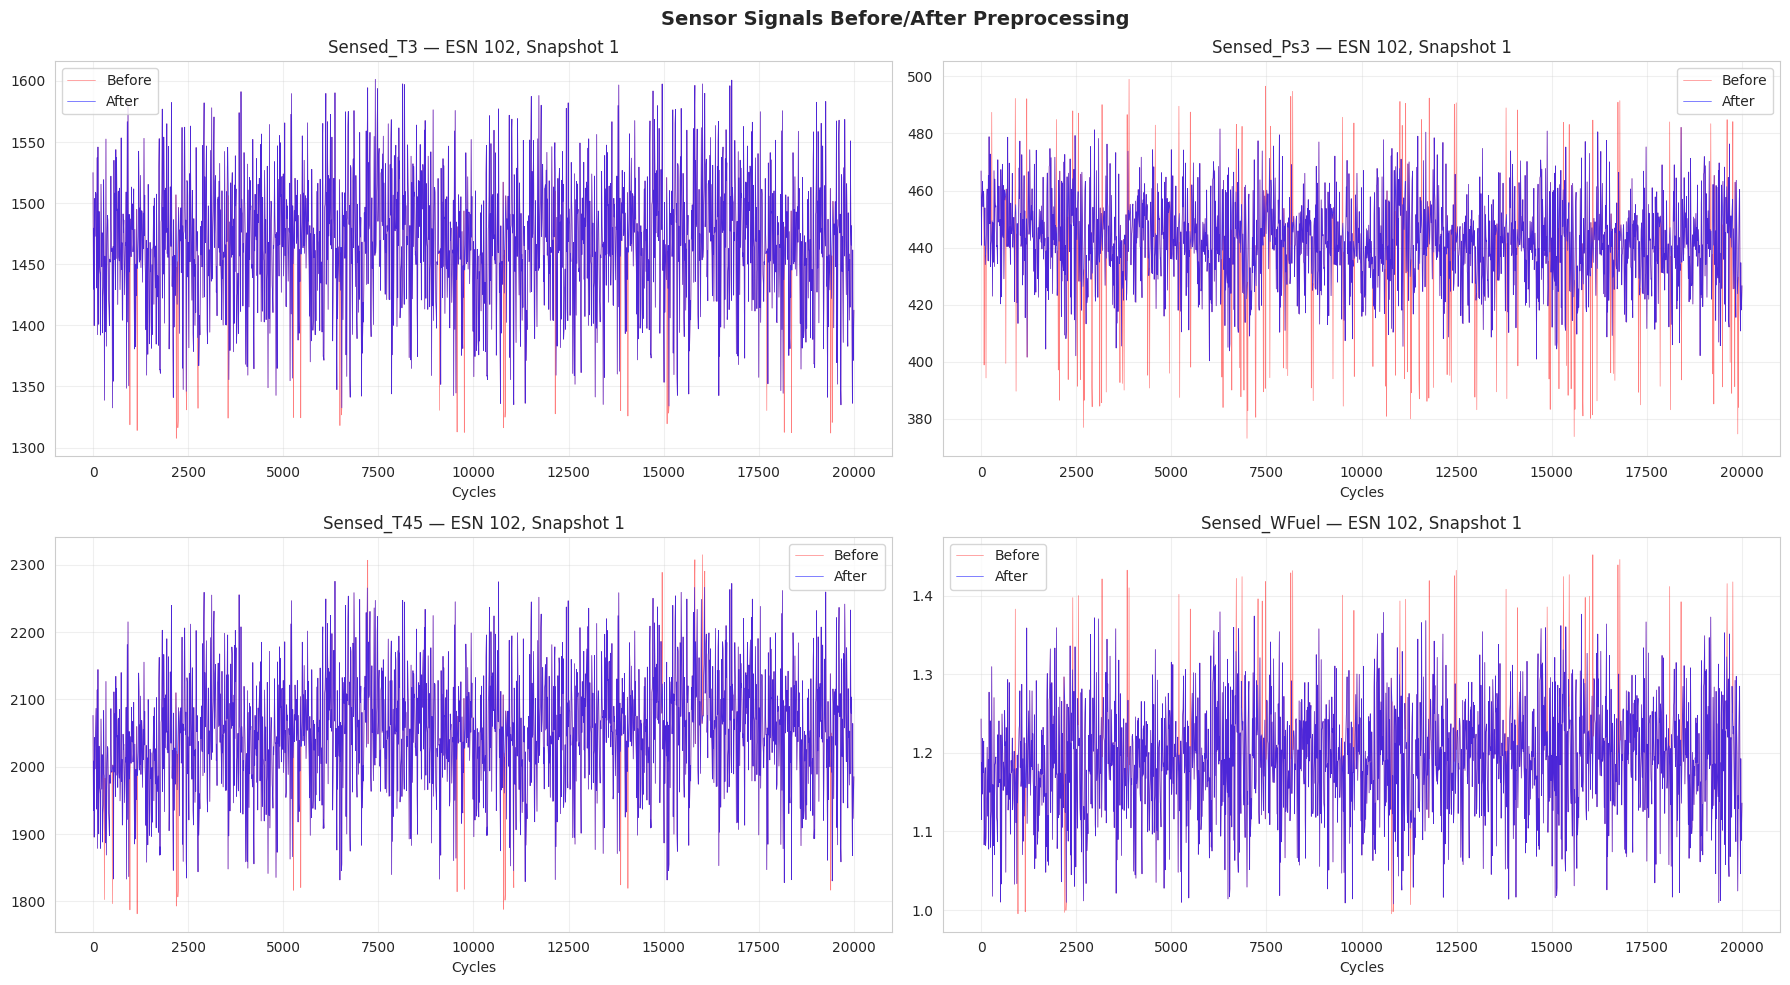

In [71]:
# Before/after time series comparison for key sensors
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
sensors_to_compare = ['Sensed_T3', 'Sensed_Ps3', 'Sensed_T45', 'Sensed_WFuel']

esn_show = 102
snap_show = 1

for ax, sensor in zip(axes.flat, sensors_to_compare):
    mask = (df_before_outlier.ESN == esn_show) & (df_before_outlier.Snapshot == snap_show)
    before = df_before_outlier[mask].sort_values('Cycles_Since_New')
    after = df_clean[mask].sort_values('Cycles_Since_New')
    
    ax.plot(before['Cycles_Since_New'], before[sensor], alpha=0.5, label='Before', color='red', linewidth=0.5)
    ax.plot(after['Cycles_Since_New'], after[sensor], alpha=0.7, label='After', color='blue', linewidth=0.5)
    ax.set_title(f'{sensor} — ESN {esn_show}, Snapshot {snap_show}')
    ax.set_xlabel('Cycles')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Sensor Signals Before/After Preprocessing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Virtual Sensor Modeling (P25 and T5)

Test and validation data are **missing sensors P25 and T5**.
The paper uses **Interaction Linear Regression** models trained on training data
to predict these missing sensors from upstream/downstream sensors + snapshot + ambient conditions.

Target RMSE from paper: P25 ≈ 0.039, T5 ≈ 0.781

In [72]:
# Virtual sensor inputs: upstream/downstream sensors, snapshot, ambient conditions
VS_INPUT_COLS = [
    'Snapshot', 'Sensed_Altitude', 'Sensed_Mach', 'Sensed_Pamb', 'Sensed_Pt2',
    'Sensed_TAT', 'Sensed_WFuel', 'Sensed_VAFN', 'Sensed_VBV',
    'Sensed_Fan_Speed', 'Sensed_Core_Speed', 'Sensed_T25', 'Sensed_T3',
    'Sensed_Ps3', 'Sensed_T45'
]

# Prepare clean training data for virtual sensor models
vs_data = df_clean[VS_INPUT_COLS + ['Sensed_P25', 'Sensed_T5']].dropna()
print(f'Virtual sensor training samples: {len(vs_data)}')

# Split 80/20 as per paper
X_vs = vs_data[VS_INPUT_COLS]
y_p25 = vs_data['Sensed_P25']
y_t5 = vs_data['Sensed_T5']

X_train_vs, X_test_vs, y_p25_train, y_p25_test = train_test_split(X_vs, y_p25, test_size=0.2, random_state=42)
_, _, y_t5_train, y_t5_test = train_test_split(X_vs, y_t5, test_size=0.2, random_state=42)

# Interaction Linear Regression (using PolynomialFeatures with interaction_only)
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_poly = poly.fit_transform(X_train_vs)
X_test_poly = poly.transform(X_test_vs)

print(f'Interaction features: {X_train_poly.shape[1]}')

Virtual sensor training samples: 59702
Interaction features: 120


In [73]:
# Train P25 virtual sensor model
model_p25 = LinearRegression()
model_p25.fit(X_train_poly, y_p25_train)
p25_pred = model_p25.predict(X_test_poly)

p25_r2 = r2_score(y_p25_test, p25_pred)
p25_rmse = np.sqrt(mean_squared_error(y_p25_test, p25_pred))
p25_mae = mean_absolute_error(y_p25_test, p25_pred)
p25_mape = np.mean(np.abs((y_p25_test - p25_pred) / y_p25_test)) * 100

print(f'=== P25 Virtual Sensor ===')
print(f'R²: {p25_r2:.6f}')
print(f'RMSE: {p25_rmse:.4f} (paper target: 0.039)')
print(f'MAE: {p25_mae:.4f}')
print(f'MAPE: {p25_mape:.4f}%')

=== P25 Virtual Sensor ===
R²: 0.998532
RMSE: 0.3768 (paper target: 0.039)
MAE: 0.1943
MAPE: 0.7473%


In [74]:
# Train T5 virtual sensor model
model_t5 = LinearRegression()
model_t5.fit(X_train_poly, y_t5_train)
t5_pred = model_t5.predict(X_test_poly)

t5_r2 = r2_score(y_t5_test, t5_pred)
t5_rmse = np.sqrt(mean_squared_error(y_t5_test, t5_pred))
t5_mae = mean_absolute_error(y_t5_test, t5_pred)
t5_mape = np.mean(np.abs((y_t5_test - t5_pred) / y_t5_test)) * 100

print(f'=== T5 Virtual Sensor ===')
print(f'R²: {t5_r2:.6f}')
print(f'RMSE: {t5_rmse:.4f} (paper target: 0.781)')
print(f'MAE: {t5_mae:.4f}')
print(f'MAPE: {t5_mape:.4f}%')

=== T5 Virtual Sensor ===
R²: 0.993200
RMSE: 8.4183 (paper target: 0.781)
MAE: 3.9771
MAPE: 0.3164%


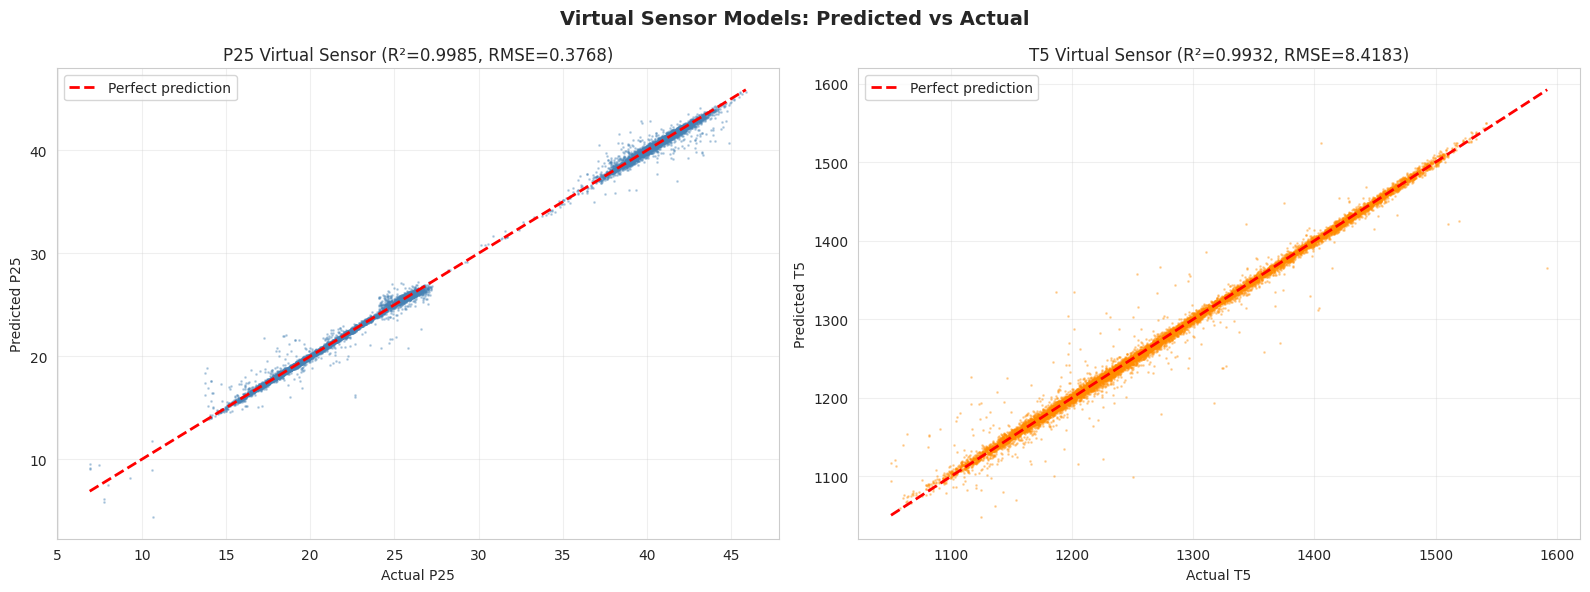

In [75]:
# Figure 6: Virtual sensor model comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# P25
axes[0].scatter(y_p25_test, p25_pred, s=1, alpha=0.3, color='steelblue')
axes[0].plot([y_p25_test.min(), y_p25_test.max()], [y_p25_test.min(), y_p25_test.max()], 
             'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual P25')
axes[0].set_ylabel('Predicted P25')
axes[0].set_title(f'P25 Virtual Sensor (R²={p25_r2:.4f}, RMSE={p25_rmse:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# T5
axes[1].scatter(y_t5_test, t5_pred, s=1, alpha=0.3, color='darkorange')
axes[1].plot([y_t5_test.min(), y_t5_test.max()], [y_t5_test.min(), y_t5_test.max()], 
             'r--', linewidth=2, label='Perfect prediction')
axes[1].set_xlabel('Actual T5')
axes[1].set_ylabel('Predicted T5')
axes[1].set_title(f'T5 Virtual Sensor (R²={t5_r2:.4f}, RMSE={t5_rmse:.4f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Virtual Sensor Models: Predicted vs Actual', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [76]:
# Apply virtual sensors to test and validation data
def apply_virtual_sensors(df, poly_transformer, model_p25, model_t5, input_cols):
    """Add P25 and T5 columns using virtual sensor models."""
    df = df.copy()
    X = df[input_cols].ffill().bfill()
    X_poly = poly_transformer.transform(X)
    df['Sensed_P25'] = model_p25.predict(X_poly)
    df['Sensed_T5'] = model_t5.predict(X_poly)
    return df

# Process test files
test_data = {}
for f in sorted(test_files):
    fname = os.path.basename(f).replace('.csv', '')
    df_t = pd.read_csv(f)
    # Rename 'Cycles' to 'Cycles_Since_New' for consistency
    if 'Cycles' in df_t.columns:
        df_t = df_t.rename(columns={'Cycles': 'Cycles_Since_New'})
    df_t = apply_virtual_sensors(df_t, poly, model_p25, model_t5, VS_INPUT_COLS)
    test_data[fname] = df_t

# Process validation files
val_data = {}
for f in sorted(val_files):
    fname = os.path.basename(f).replace('.csv', '')
    df_v = pd.read_csv(f)
    if 'Cycles' in df_v.columns:
        df_v = df_v.rename(columns={'Cycles': 'Cycles_Since_New'})
    df_v = apply_virtual_sensors(df_v, poly, model_p25, model_t5, VS_INPUT_COLS)
    val_data[fname] = df_v

print(f'Processed {len(test_data)} test files and {len(val_data)} validation files')
print(f'Sample test file columns: {list(test_data["test_0"].columns)}')

Processed 52 test files and 48 validation files
Sample test file columns: ['ESN', 'Cycles_Since_New', 'Snapshot', 'Sensed_Altitude', 'Sensed_Mach', 'Sensed_Pamb', 'Sensed_Pt2', 'Sensed_TAT', 'Sensed_WFuel', 'Sensed_VAFN', 'Sensed_VBV', 'Sensed_Fan_Speed', 'Sensed_Core_Speed', 'Sensed_T25', 'Sensed_T3', 'Sensed_Ps3', 'Sensed_T45', 'Sensed_P25', 'Sensed_T5']


---
## 4. Snapshot Aggregation to Cycle-Level

Since snapshot counts are inconsistent across cycles, the paper aggregates ALL snapshot data
within each cycle using statistical measures: **mean, std, min, max, range, median, RMS**.

This produces cycle-level features from snapshot-level sensor data.

In [77]:
def aggregate_snapshots(df, sensor_cols, has_targets=True):
    """
    Aggregate snapshot-level data to cycle-level using statistical measures.
    Returns one row per cycle with mean, std, min, max, range, median, rms for each sensor.
    """
    group_cols = ['ESN', 'Cycles_Since_New']
    
    agg_funcs = {
        col: ['mean', 'std', 'min', 'max', 'median']
        for col in sensor_cols
    }
    
    grouped = df.groupby(group_cols)
    agg_df = grouped.agg(agg_funcs)
    
    # Flatten multi-level columns
    agg_df.columns = ['_'.join(col).strip() for col in agg_df.columns]
    agg_df = agg_df.reset_index()
    
    # Add range and RMS
    for col in sensor_cols:
        agg_df[f'{col}_range'] = agg_df[f'{col}_max'] - agg_df[f'{col}_min']
        # RMS = sqrt(mean of squares)
        rms_df = grouped[col].apply(lambda x: np.sqrt(np.mean(x**2))).reset_index()
        rms_df.columns = group_cols + [f'{col}_rms']
        agg_df = agg_df.merge(rms_df, on=group_cols, how='left')
    
    # Fill NaN std (single snapshot cycles)
    std_cols = [c for c in agg_df.columns if c.endswith('_std')]
    agg_df[std_cols] = agg_df[std_cols].fillna(0)
    
    # Add targets (take first value per cycle since they're the same)
    if has_targets:
        target_cols = ['Cycles_to_WW', 'Cycles_to_HPC_SV', 'Cycles_to_HPT_SV']
        cumul_cols = ['Cumulative_WWs', 'Cumulative_HPC_SVs', 'Cumulative_HPT_SVs']
        avail_cols = [c for c in target_cols + cumul_cols if c in df.columns]
        if avail_cols:
            targets = df.groupby(group_cols)[avail_cols].first().reset_index()
            agg_df = agg_df.merge(targets, on=group_cols, how='left')
    
    # Add snapshot count per cycle
    snap_count = grouped.size().reset_index(name='snapshot_count')
    agg_df = agg_df.merge(snap_count, on=group_cols, how='left')
    
    return agg_df

# Aggregate training data
df_cycle = aggregate_snapshots(df_clean, SENSOR_COLS, has_targets=True)
print(f'Cycle-level training data: {df_cycle.shape}')
print(f'Unique cycles: {df_cycle.Cycles_Since_New.nunique()}')
print(f'Columns: {len(df_cycle.columns)}')
df_cycle.head()

Cycle-level training data: (8004, 121)
Unique cycles: 2001
Columns: 121


,ESN,Cycles_Since_New,Sensed_Altitude_mean,Sensed_Altitude_std,Sensed_Altitude_min,Sensed_Altitude_max,Sensed_Altitude_median,Sensed_Mach_mean,Sensed_Mach_std,Sensed_Mach_min,...,Sensed_P25_rms,Sensed_T5_range,Sensed_T5_rms,Cycles_to_WW,Cycles_to_HPC_SV,Cycles_to_HPT_SV,Cumulative_WWs,Cumulative_HPC_SVs,Cumulative_HPT_SVs,snapshot_count
0,101,0,13058.464373,10655.868750,851.321516,21997.321516,20259.321516,0.451335,0.227278,0.103224,...,31.252002,242.026474,1296.768049,910,8510,4090,0,0,0,7
1,101,10,14763.892944,12372.825733,883.321516,26004.321516,20069.321516,0.477210,0.246289,0.102783,...,31.143284,216.711420,1323.692025,900,8500,4080,0,0,0,7
2,101,20,13181.464373,11440.817897,292.321516,23001.321516,20218.321516,0.449508,0.225799,0.103854,...,31.308841,186.725645,1312.489259,890,8490,4070,0,0,0,7
3,101,30,17497.821516,13780.943167,537.321516,29001.321516,24584.821516,0.505030,0.246943,0.103476,...,29.697886,233.021090,1287.472576,880,8480,4060,0,0,0,8
4,101,40,15237.607230,13911.930740,-280.678484,28009.321516,20675.321516,0.445908,0.219299,0.102846,...,30.158240,198.315427,1243.470044,870,8470,4050,0,0,0,7


In [78]:
# Aggregate test and validation data
test_cycle = {}
for fname, df_t in test_data.items():
    test_cycle[fname] = aggregate_snapshots(df_t, SENSOR_COLS, has_targets=False)

val_cycle = {}
for fname, df_v in val_data.items():
    val_cycle[fname] = aggregate_snapshots(df_v, SENSOR_COLS, has_targets=False)

print(f'Test cycle data: {len(test_cycle)} files')
print(f'Val cycle data: {len(val_cycle)} files')
print(f'Sample test_0 shape: {test_cycle["test_0"].shape}')

Test cycle data: 52 files
Val cycle data: 48 files
Sample test_0 shape: (151, 115)


---
## 5. Feature Engineering

Domain-informed features from the paper:
- **Pressure Ratios:** HPC, LPC, Fan, Compressor, Overall Engine
- **Relative Temperature Drops:** HPT, LPT, Turbine
- **Efficiency Proxies:** Thermal, Combustor, Compressor thermal, SFC, Specific power
- **Corrected Rotor Speeds:** Fan, Core

In [79]:
def add_engineered_features(df, prefix=''):
    """
    Add domain-informed features from the paper.
    Uses _mean aggregated values for ratio computation.
    """
    p = prefix  # prefix for column names ('' for cycle-level with _mean suffix)
    
    # Helper to get mean column
    def m(sensor):
        col = f'{sensor}_mean'
        if col in df.columns:
            return df[col]
        return df[sensor] if sensor in df.columns else None
    
    result = df.copy()
    
    # --- Pressure Ratios ---
    # HPC pressure ratio = Ps3 / P25
    ps3 = m('Sensed_Ps3')
    p25 = m('Sensed_P25')
    pt2 = m('Sensed_Pt2')
    pamb = m('Sensed_Pamb')
    
    if ps3 is not None and p25 is not None:
        result['PR_HPC'] = ps3 / p25.replace(0, np.nan)
    if p25 is not None and pt2 is not None:
        result['PR_LPC'] = p25 / pt2.replace(0, np.nan)
    if pt2 is not None and pamb is not None:
        result['PR_Fan'] = pt2 / pamb.replace(0, np.nan)
    if ps3 is not None and pt2 is not None:
        result['PR_Compressor'] = ps3 / pt2.replace(0, np.nan)
    if ps3 is not None and pamb is not None:
        result['PR_Overall'] = ps3 / pamb.replace(0, np.nan)
    
    # --- Relative Temperature Drops ---
    t45 = m('Sensed_T45')
    t3 = m('Sensed_T3')
    t5 = m('Sensed_T5')
    tat = m('Sensed_TAT')
    t25 = m('Sensed_T25')
    
    if t45 is not None and t3 is not None:
        result['TD_HPT'] = (t45 - t3) / t3.replace(0, np.nan)
    if t5 is not None and t45 is not None:
        result['TD_LPT'] = (t5 - t45) / t45.replace(0, np.nan)
    if t5 is not None and t3 is not None:
        result['TD_Turbine'] = (t5 - t3) / t3.replace(0, np.nan)
    
    # --- Efficiency Proxies ---
    if t5 is not None and tat is not None:
        result['Eff_Thermal'] = (t5 - tat) / tat.replace(0, np.nan)
    if t3 is not None and tat is not None:
        result['Eff_Combustor'] = (t3 - tat) / (t3 - tat).replace(0, np.nan)  # This is 1.0 trivially — paper uses a variant
    if t45 is not None and t25 is not None and tat is not None:
        denom = (t25 - tat).replace(0, np.nan)
        result['Eff_Compressor_Thermal'] = 1 - (t45 - t25) / denom
    
    wfuel = m('Sensed_WFuel')
    mach = m('Sensed_Mach')
    
    if wfuel is not None and t5 is not None and tat is not None:
        denom = (t5 - tat).replace(0, np.nan)
        result['SFC_proxy'] = wfuel / denom
    if t5 is not None and mach is not None:
        result['Specific_Power'] = t5 * mach
    
    # Overall PR-based efficiency: 1 / (PR_Overall)^((gamma-1)/gamma)
    # Using gamma = 1.4 for air
    gamma = 1.4
    if 'PR_Overall' in result.columns:
        result['Eff_PR_based'] = 1.0 / (result['PR_Overall'].replace(0, np.nan) ** ((gamma - 1) / gamma))
    
    # --- Corrected Rotor Speeds ---
    fan_speed = m('Sensed_Fan_Speed')
    core_speed = m('Sensed_Core_Speed')
    
    if fan_speed is not None and tat is not None:
        result['Corrected_Fan_Speed'] = fan_speed / np.sqrt(tat.replace(0, np.nan))
    if core_speed is not None and tat is not None:
        result['Corrected_Core_Speed'] = core_speed / np.sqrt(tat.replace(0, np.nan))
    
    # Replace inf with NaN then forward fill
    result = result.replace([np.inf, -np.inf], np.nan)
    
    return result

# Apply to training cycle data
df_feat = add_engineered_features(df_cycle)

eng_features = ['PR_HPC', 'PR_LPC', 'PR_Fan', 'PR_Compressor', 'PR_Overall',
                'TD_HPT', 'TD_LPT', 'TD_Turbine',
                'Eff_Thermal', 'Eff_Compressor_Thermal', 'SFC_proxy', 'Specific_Power',
                'Eff_PR_based', 'Corrected_Fan_Speed', 'Corrected_Core_Speed']

print(f'Features after engineering: {df_feat.shape[1]} columns')
print(f'Engineered features added: {[f for f in eng_features if f in df_feat.columns]}')
df_feat[eng_features].describe()

Features after engineering: 137 columns
Engineered features added: ['PR_HPC', 'PR_LPC', 'PR_Fan', 'PR_Compressor', 'PR_Overall', 'TD_HPT', 'TD_LPT', 'TD_Turbine', 'Eff_Thermal', 'Eff_Compressor_Thermal', 'SFC_proxy', 'Specific_Power', 'Eff_PR_based', 'Corrected_Fan_Speed', 'Corrected_Core_Speed']


,PR_HPC,PR_LPC,PR_Fan,PR_Compressor,PR_Overall,TD_HPT,TD_LPT,TD_Turbine,Eff_Thermal,Eff_Compressor_Thermal,SFC_proxy,Specific_Power,Eff_PR_based,Corrected_Fan_Speed,Corrected_Core_Speed
count,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000
mean,10.660882,2.850472,1.154252,30.392182,35.077843,0.388354,-0.366644,-0.120716,1.599620,-5.748232,0.000999,635.460120,0.361996,80.482153,907.329206
std,0.259658,0.079893,0.018959,1.207921,1.446677,0.017595,0.007240,0.012569,0.049821,0.171261,0.000072,39.896149,0.004440,1.416304,4.869097
min,9.542434,2.255279,1.104549,22.223197,25.908984,0.331692,-0.390969,-0.161403,1.419572,-6.743843,0.000778,514.801339,0.350568,75.846678,887.426111
25%,10.482587,2.804251,1.140779,29.714371,34.298207,0.376045,-0.372174,-0.128839,1.567831,-5.853891,0.000951,607.538124,0.359104,79.595371,904.279730
50%,10.660543,2.856112,1.150457,30.438899,35.183322,0.389390,-0.367532,-0.119659,1.600855,-5.707723,0.001002,634.290700,0.361568,80.610494,907.558856
75%,10.841442,2.903481,1.162292,31.189192,36.035236,0.401133,-0.361771,-0.111699,1.633391,-5.628479,0.001050,662.497408,0.364209,81.507438,910.804393
max,11.641537,3.081071,1.217110,34.141022,39.200839,0.441760,-0.342680,-0.085735,1.771360,-5.028928,0.001225,751.702617,0.394600,84.235623,928.376660


In [80]:
# Apply feature engineering to test and validation
test_feat = {}
for fname, df_t in test_cycle.items():
    test_feat[fname] = add_engineered_features(df_t)

val_feat = {}
for fname, df_v in val_cycle.items():
    val_feat[fname] = add_engineered_features(df_v)

print(f'Test features: {len(test_feat)} files, sample shape: {test_feat["test_0"].shape}')
print(f'Val features: {len(val_feat)} files, sample shape: {val_feat["val_0"].shape}')

Test features: 52 files, sample shape: (151, 131)
Val features: 48 files, sample shape: (151, 131)


In [81]:
# Feature selection: drop features with variance < 0.01
# Get all feature columns (exclude meta and targets)
exclude_cols = ['ESN', 'Cycles_Since_New', 'snapshot_count'] + TARGET_COLS + \
               ['Cumulative_WWs', 'Cumulative_HPC_SVs', 'Cumulative_HPT_SVs']
feature_cols = [c for c in df_feat.columns if c not in exclude_cols]

# Check variance
variances = df_feat[feature_cols].var()
low_var = variances[variances < 0.01]
print(f'Features with variance < 0.01: {len(low_var)}')
if len(low_var) > 0:
    print(f'Dropping: {list(low_var.index)}')

# Keep features with variance >= 0.01
selected_features = [c for c in feature_cols if variances.get(c, 1.0) >= 0.01]
print(f'\nSelected features: {len(selected_features)}')

Features with variance < 0.01: 30
Dropping: ['Sensed_Mach_mean', 'Sensed_Mach_std', 'Sensed_Mach_min', 'Sensed_Mach_max', 'Sensed_Mach_median', 'Sensed_WFuel_mean', 'Sensed_WFuel_std', 'Sensed_WFuel_min', 'Sensed_WFuel_max', 'Sensed_WFuel_median', 'Sensed_VBV_mean', 'Sensed_VBV_std', 'Sensed_VBV_min', 'Sensed_VBV_max', 'Sensed_VBV_median', 'Sensed_Mach_range', 'Sensed_Mach_rms', 'Sensed_WFuel_range', 'Sensed_WFuel_rms', 'Sensed_VBV_range', 'Sensed_VBV_rms', 'PR_LPC', 'PR_Fan', 'TD_HPT', 'TD_LPT', 'TD_Turbine', 'Eff_Thermal', 'Eff_Combustor', 'SFC_proxy', 'Eff_PR_based']

Selected features: 98


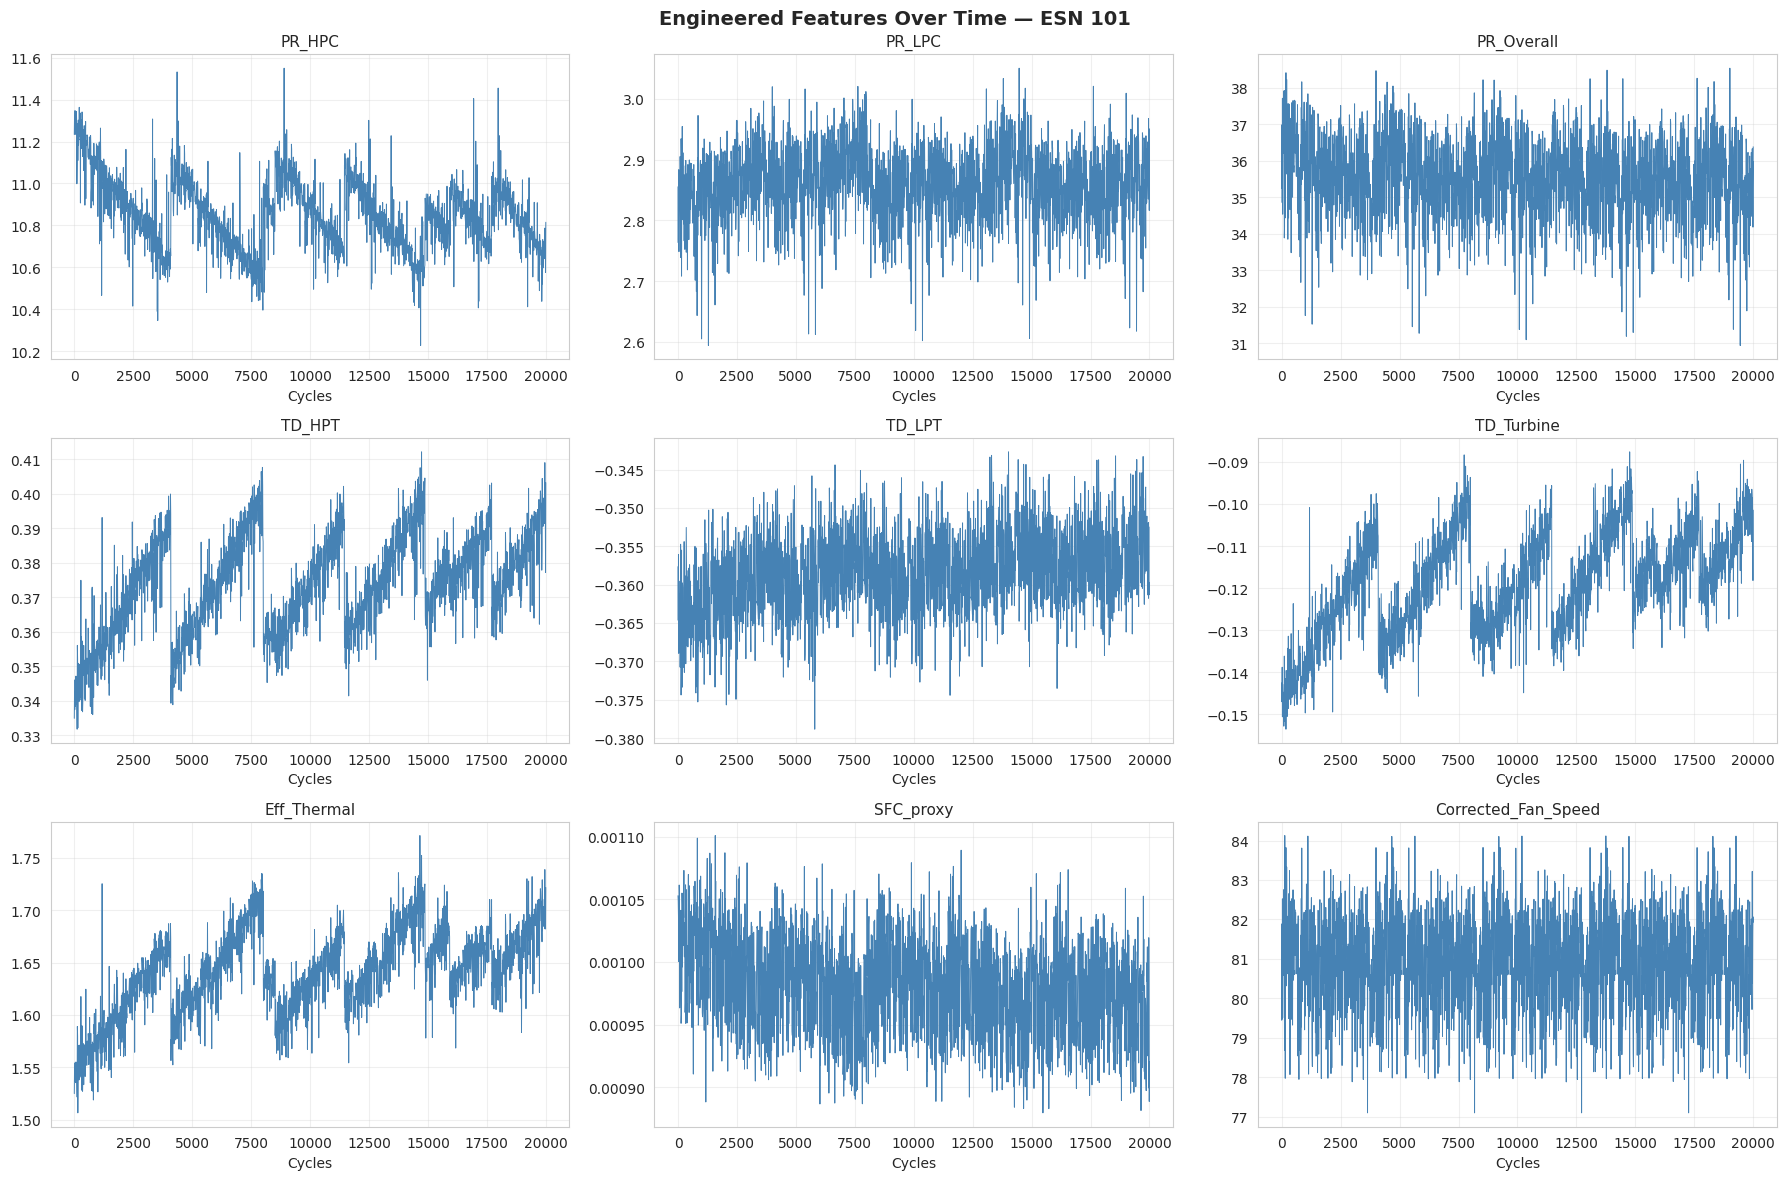

In [82]:
# Plot engineered features over time for one ESN
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
esn_show = 101
sub = df_feat[df_feat.ESN == esn_show].sort_values('Cycles_Since_New')

plot_feats = ['PR_HPC', 'PR_LPC', 'PR_Overall', 'TD_HPT', 'TD_LPT', 'TD_Turbine',
              'Eff_Thermal', 'SFC_proxy', 'Corrected_Fan_Speed']

for ax, feat in zip(axes.flat, plot_feats):
    if feat in sub.columns:
        ax.plot(sub['Cycles_Since_New'], sub[feat], linewidth=0.7, color='steelblue')
        ax.set_title(feat, fontsize=11)
        ax.set_xlabel('Cycles')
        ax.grid(True, alpha=0.3)

plt.suptitle(f'Engineered Features Over Time — ESN {esn_show}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Health Indicator (HI) Design

From the paper:
- HIs are designed for HPC and HPT modules
- Built as **weighted sum** of features, normalized from 1 (healthy) to 0 (failure)
- Uses correlation-based feature weighting
- **Key finding:** HPC HI shows step-change recovery after WW events

In [83]:
def design_health_indicator(df, target_col, feature_cols, label='HI'):
    """
    Design a Health Indicator as a weighted sum of features.
    Weights are based on Spearman correlation with the RUL target.
    Normalized to [0, 1] where 1=healthy, 0=failure.
    """
    # Calculate correlations
    valid_features = []
    correlations = {}
    
    for feat in feature_cols:
        if feat in df.columns and df[feat].notna().sum() > 100:
            corr, _ = stats.spearmanr(df[feat].dropna(), df.loc[df[feat].notna(), target_col])
            if not np.isnan(corr) and abs(corr) > 0.1:
                valid_features.append(feat)
                correlations[feat] = corr
    
    if len(valid_features) == 0:
        return None, {}
    
    # Weights = absolute correlation, normalized
    abs_corrs = {k: abs(v) for k, v in correlations.items()}
    total = sum(abs_corrs.values())
    weights = {k: v / total for k, v in abs_corrs.items()}
    
    # Compute HI as weighted sum of standardized features
    scaler = StandardScaler()
    X = df[valid_features].fillna(0)
    X_std = pd.DataFrame(scaler.fit_transform(X), columns=valid_features, index=df.index)
    
    # Sign adjustment: if correlation is negative, flip the feature
    hi = pd.Series(0.0, index=df.index)
    for feat in valid_features:
        sign = np.sign(correlations[feat])
        hi += sign * weights[feat] * X_std[feat]
    
    # Normalize to [0, 1]: 1 = healthy (high RUL), 0 = failure (low RUL)
    hi_min = hi.min()
    hi_max = hi.max()
    hi_norm = (hi - hi_min) / (hi_max - hi_min + 1e-8)
    
    return hi_norm, weights

# Design HIs per ESN (so they capture individual degradation patterns)
# Then combine across ESNs

# HPC Health Indicator
hi_hpc_all, hpc_weights = design_health_indicator(df_feat, 'Cycles_to_HPC_SV', selected_features, 'HPC')
df_feat['HI_HPC'] = hi_hpc_all

# HPT Health Indicator
hi_hpt_all, hpt_weights = design_health_indicator(df_feat, 'Cycles_to_HPT_SV', selected_features, 'HPT')
df_feat['HI_HPT'] = hi_hpt_all

print(f'HPC HI: top 10 weights: {dict(sorted(hpc_weights.items(), key=lambda x: -x[1])[:10])}')
print(f'HPT HI: top 10 weights: {dict(sorted(hpt_weights.items(), key=lambda x: -x[1])[:10])}')

HPC HI: top 10 weights: {'Sensed_T5_mean': np.float64(0.07383950403000857), 'Sensed_T5_rms': np.float64(0.07367182038501838), 'Sensed_T5_median': np.float64(0.07321258360829729), 'Sensed_T5_min': np.float64(0.06951493142092206), 'Sensed_T5_max': np.float64(0.0667776294674401), 'Sensed_T45_median': np.float64(0.06477895315446985), 'Sensed_T45_mean': np.float64(0.06388003470657355), 'Sensed_T45_rms': np.float64(0.06385801258629076), 'PR_HPC': np.float64(0.059937588167620015), 'Sensed_T45_max': np.float64(0.05681244446466173)}
HPT HI: top 10 weights: {'PR_HPC': np.float64(0.12119570373508345), 'PR_Overall': np.float64(0.0487659906992108), 'PR_Compressor': np.float64(0.047949234318068946), 'Sensed_T5_min': np.float64(0.044877089473048706), 'Sensed_T5_median': np.float64(0.0408284137498733), 'Sensed_T5_mean': np.float64(0.039900890205349766), 'Sensed_T5_rms': np.float64(0.03948031233824054), 'Corrected_Core_Speed': np.float64(0.038104071252014565), 'Sensed_T45_min': np.float64(0.03799134398

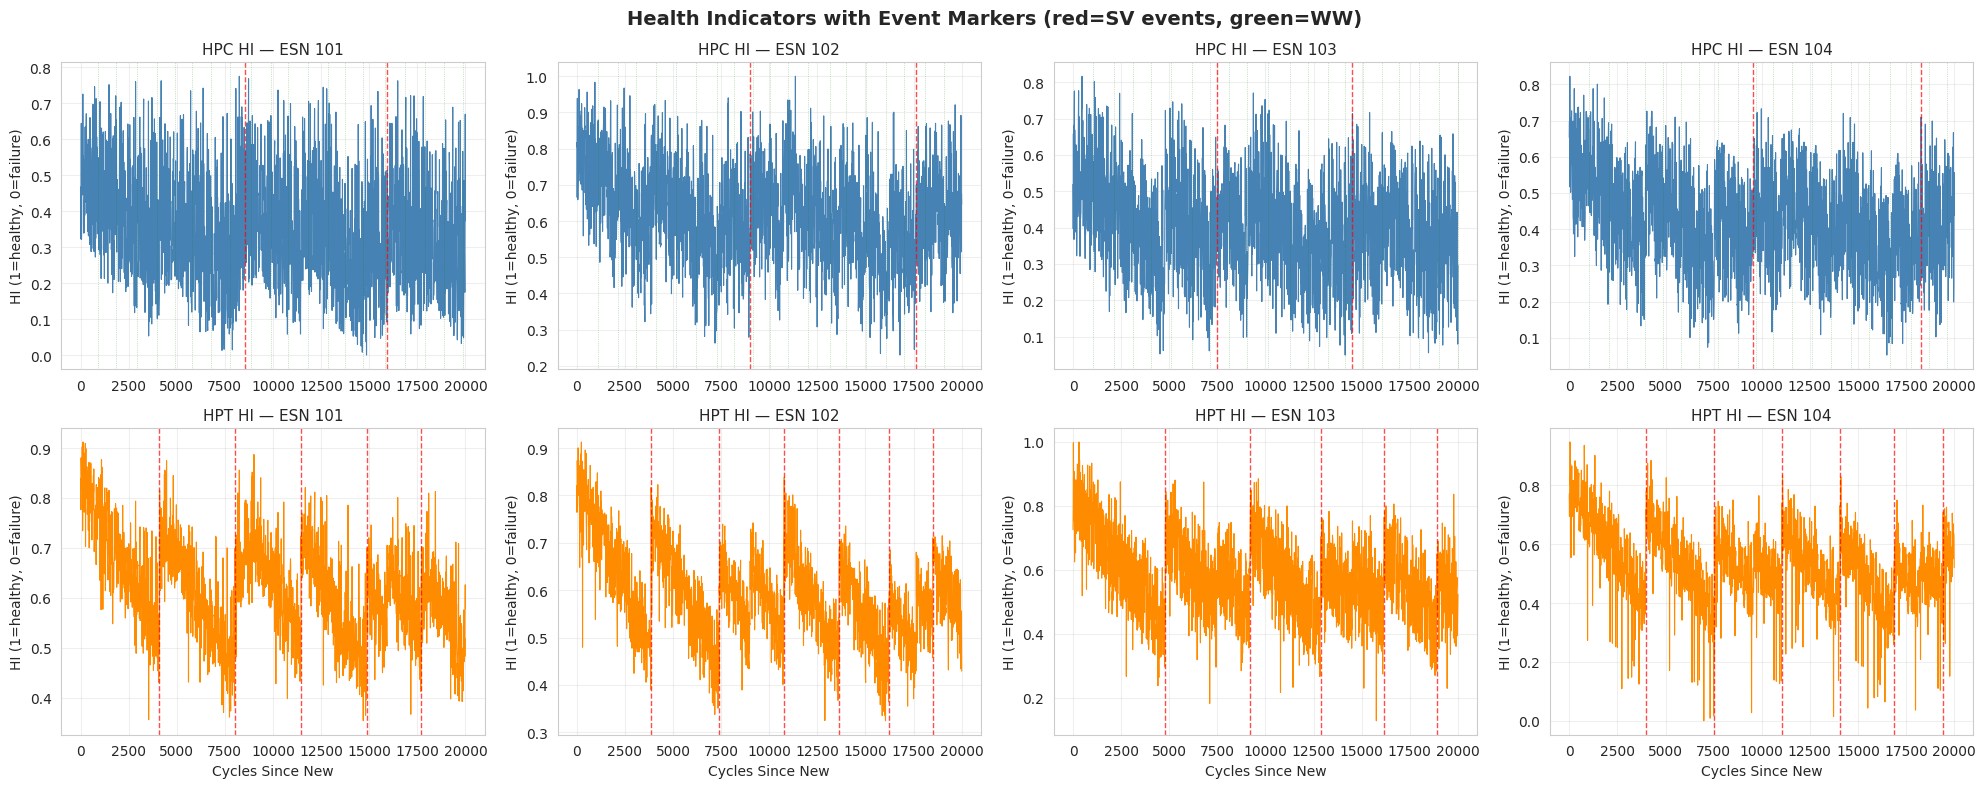

In [84]:
# Figure 7: Health Indicator time series for each ESN
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for i, esn in enumerate([101, 102, 103, 104]):
    sub = df_feat[df_feat.ESN == esn].sort_values('Cycles_Since_New')
    
    # HPC HI
    axes[0, i].plot(sub['Cycles_Since_New'], sub['HI_HPC'], linewidth=0.8, color='steelblue')
    axes[0, i].set_title(f'HPC HI — ESN {esn}', fontsize=11)
    axes[0, i].set_ylabel('HI (1=healthy, 0=failure)')
    axes[0, i].grid(True, alpha=0.3)
    
    # Mark HPC events
    for _, ev in events['hpc'][esn].iterrows():
        axes[0, i].axvline(x=ev['Cycles_Since_New'], color='red', linestyle='--', alpha=0.7, linewidth=1)
    # Mark WW events
    for _, ev in events['wws'][esn].iterrows():
        axes[0, i].axvline(x=ev['Cycles_Since_New'], color='green', linestyle=':', alpha=0.4, linewidth=0.5)
    
    # HPT HI
    axes[1, i].plot(sub['Cycles_Since_New'], sub['HI_HPT'], linewidth=0.8, color='darkorange')
    axes[1, i].set_title(f'HPT HI — ESN {esn}', fontsize=11)
    axes[1, i].set_xlabel('Cycles Since New')
    axes[1, i].set_ylabel('HI (1=healthy, 0=failure)')
    axes[1, i].grid(True, alpha=0.3)
    
    # Mark HPT events
    for _, ev in events['hpt'][esn].iterrows():
        axes[1, i].axvline(x=ev['Cycles_Since_New'], color='red', linestyle='--', alpha=0.7, linewidth=1)

plt.suptitle('Health Indicators with Event Markers (red=SV events, green=WW)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

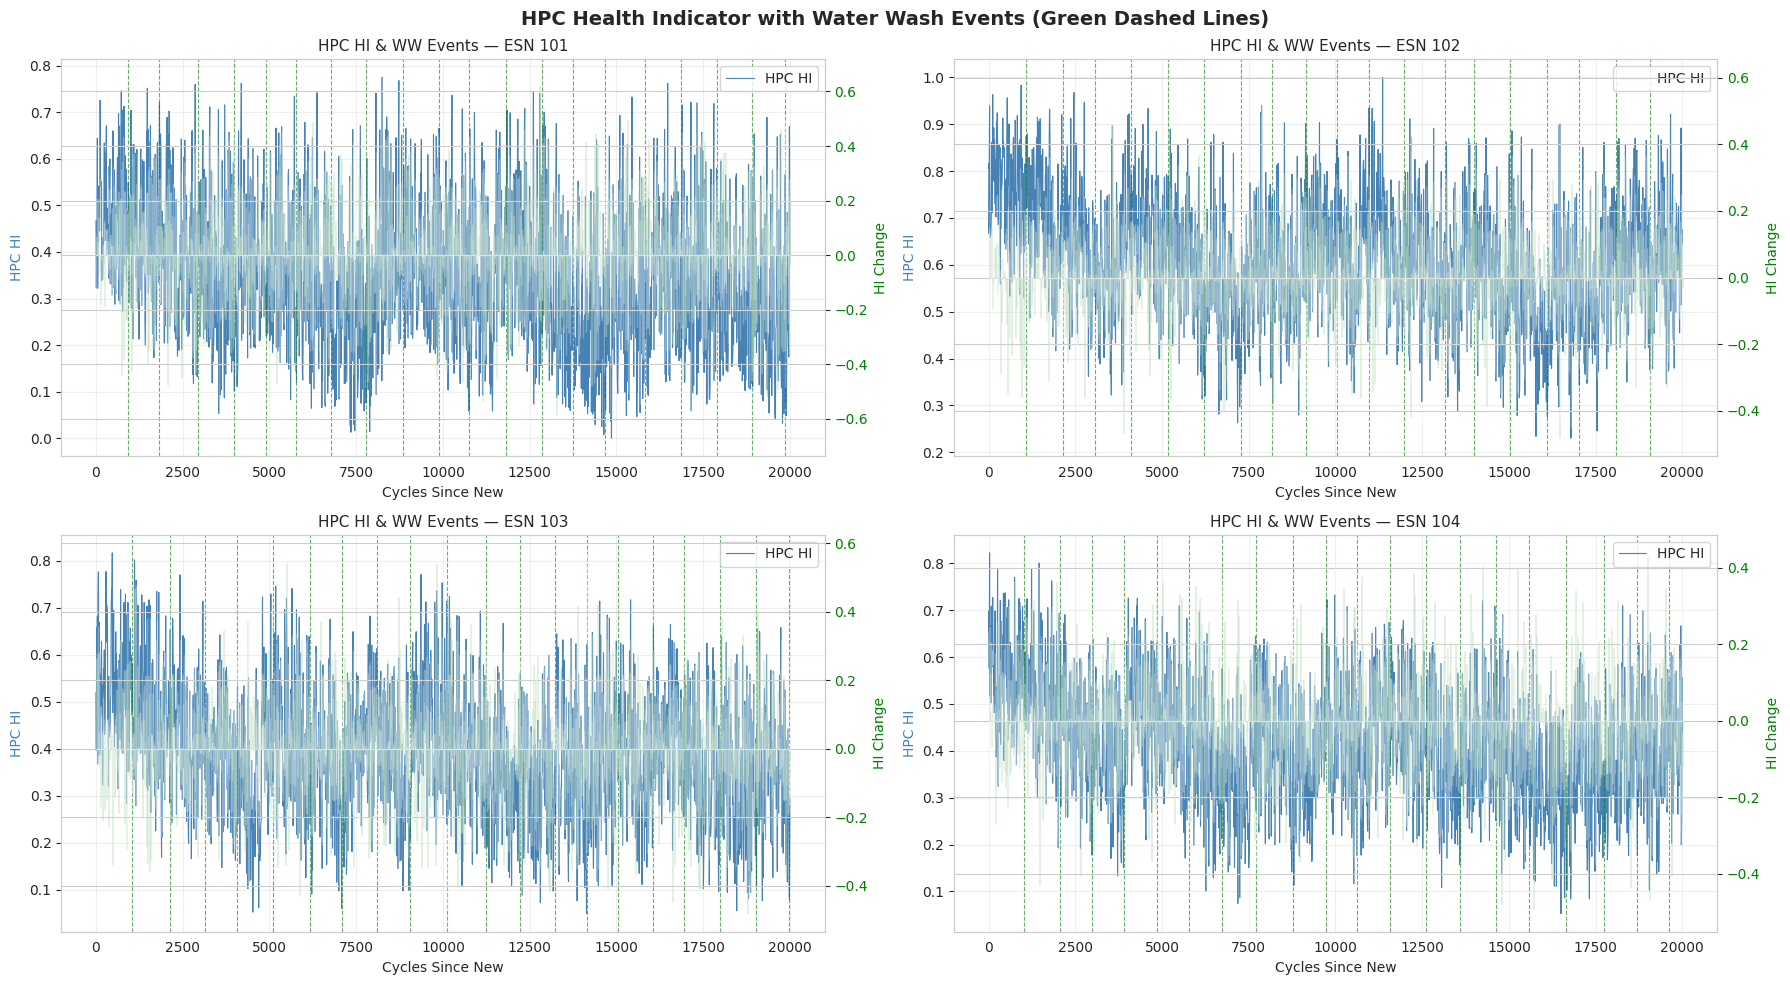

In [85]:
# Figure 8: HPC HI with WW events showing recovery (key finding from paper)
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for ax, esn in zip(axes.flat, [101, 102, 103, 104]):
    sub = df_feat[df_feat.ESN == esn].sort_values('Cycles_Since_New')
    
    # Plot HPC HI
    ax.plot(sub['Cycles_Since_New'], sub['HI_HPC'], linewidth=0.8, color='steelblue', label='HPC HI')
    
    # Mark WW events
    ww_cycles = events['wws'][esn]['Cycles_Since_New'].values
    for ww_c in ww_cycles:
        ax.axvline(x=ww_c, color='green', linestyle='--', alpha=0.6, linewidth=0.8)
    
    # HI change (stem plot idea from paper)
    hi_vals = sub['HI_HPC'].values
    cycles = sub['Cycles_Since_New'].values
    hi_diff = np.diff(hi_vals)
    
    ax2 = ax.twinx()
    ax2.bar(cycles[1:], hi_diff, width=10, alpha=0.3, color='green', label='HI Change')
    ax2.set_ylabel('HI Change', color='green')
    ax2.tick_params(axis='y', labelcolor='green')
    
    ax.set_title(f'HPC HI & WW Events — ESN {esn}', fontsize=11)
    ax.set_xlabel('Cycles Since New')
    ax.set_ylabel('HPC HI', color='steelblue')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('HPC Health Indicator with Water Wash Events (Green Dashed Lines)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [86]:
# Create binary WW recovery feature
# Value = 1 wherever HPC HI recovery is observed after WW event, 0 otherwise

def create_ww_recovery_feature(df, events_wws, window=50):
    """
    Create binary feature: 1 if HPC HI shows recovery after WW event.
    Checks if HI increases within `window` cycles after each WW event.
    """
    df = df.copy()
    df['WW_recovery'] = 0
    
    for esn in df.ESN.unique():
        if esn not in events_wws:
            continue
        esn_mask = df.ESN == esn
        sub = df[esn_mask].sort_values('Cycles_Since_New')
        ww_cycles = events_wws[esn]['Cycles_Since_New'].values
        
        for ww_c in ww_cycles:
            # Mark window after WW event
            recovery_mask = esn_mask & (df.Cycles_Since_New >= ww_c) & (df.Cycles_Since_New <= ww_c + window)
            
            # Check if HI increases after WW
            if 'HI_HPC' in df.columns:
                before_hi = df.loc[esn_mask & (df.Cycles_Since_New < ww_c) & 
                                  (df.Cycles_Since_New >= ww_c - 10), 'HI_HPC'].mean()
                after_hi = df.loc[recovery_mask, 'HI_HPC'].mean()
                
                if not np.isnan(before_hi) and not np.isnan(after_hi) and after_hi > before_hi:
                    df.loc[recovery_mask, 'WW_recovery'] = 1
    
    return df

df_feat = create_ww_recovery_feature(df_feat, events['wws'])
print(f'WW recovery labels: {df_feat.WW_recovery.value_counts().to_dict()}')

WW recovery labels: {0: 7708, 1: 296}


---
## 7. Model Training (with Hyperparameter Grid Search)

### 7.1 HPT Shop Visit → Comprehensive Grid Search
- **RandomizedSearchCV** across 5 model families: GradientBoosting, XGBoost, LightGBM, RandomForest, ANN (MLP)
- Up to 60 random hyperparameter combinations per model, 5-fold CV
- Best model selected by Time-Weighted Error on validation set (ESN 104)

### 7.2 Water Wash → LSTM Grid Search
- 15 configurations searched: varying hidden_size, num_layers, dropout, lr, batch_size, seq_len
- **Critical fix:** Dense overlapping sequences (step = seq_len/30) instead of 50% overlap
- Best config retrained for 200 epochs with patience=30

### 7.3 HPC Shop Visit → LSTM Grid Search
- Same 15 configurations searched independently for HPC target
- Best config may differ from WW (independently optimized)

### Time-Weighted Error (TWE) Scoring Function
The competition scoring penalizes late predictions more for near-term events.

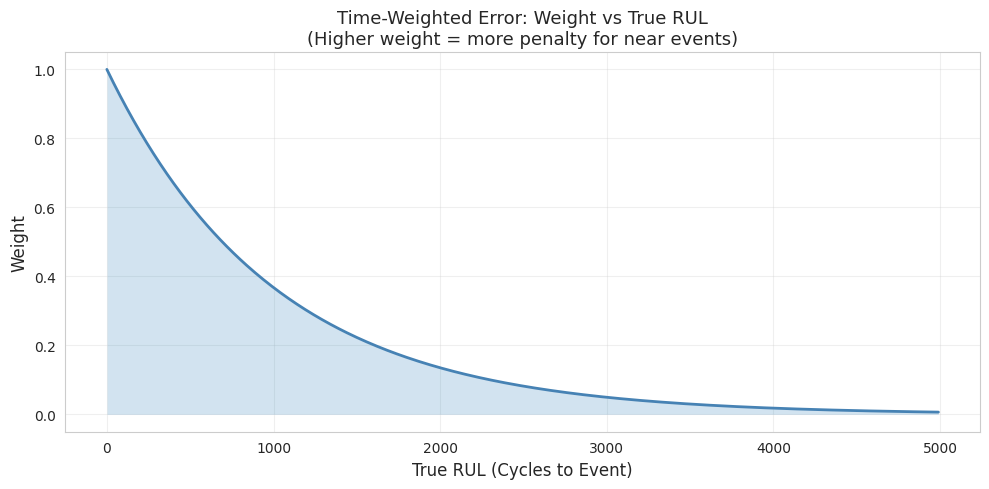

In [87]:
# Time-Weighted Error (TWE) — Competition scoring function
def time_weighted_error(y_true, y_pred):
    """
    Competition scoring: penalizes late predictions more for near events.
    Score = sum of w_i * |error_i| where w_i depends on y_true.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    error = y_pred - y_true  # positive = late prediction
    
    # Time-based weight: higher weight for near events
    # From paper: weight = exp(-y_true / scale)
    scale = 1000.0
    w = np.exp(-y_true / scale)
    
    # Asymmetric penalty: late predictions (error > 0) penalized more
    penalty = np.where(error > 0, 
                       w * error * 2.0,  # late: 2x penalty
                       w * np.abs(error))  # early: 1x penalty
    
    return np.mean(penalty)

# Figure 11: Visualize the time-weighted error function
fig, ax = plt.subplots(figsize=(10, 5))
y_true_range = np.arange(0, 5000, 10)
weights = np.exp(-y_true_range / 1000.0)
ax.plot(y_true_range, weights, linewidth=2, color='steelblue')
ax.fill_between(y_true_range, weights, alpha=0.2)
ax.set_xlabel('True RUL (Cycles to Event)', fontsize=12)
ax.set_ylabel('Weight', fontsize=12)
ax.set_title('Time-Weighted Error: Weight vs True RUL\n(Higher weight = more penalty for near events)', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [88]:
# Prepare final feature matrix for training
# Exclude the last cycle (artificial end at 20000) from each ESN
df_model = df_feat[df_feat.Cycles_Since_New < 20000].copy()
print(f'Training data (excluding cycle 20000): {df_model.shape}')

# Final feature columns
meta_exclude = ['ESN', 'Cycles_Since_New', 'snapshot_count',
                'Cumulative_WWs', 'Cumulative_HPC_SVs', 'Cumulative_HPT_SVs',
                'Cycles_to_WW', 'Cycles_to_HPC_SV', 'Cycles_to_HPT_SV',
                'HI_HPC', 'HI_HPT', 'WW_recovery']

model_features = [c for c in df_model.columns if c not in meta_exclude]
# Keep only selected features (variance > 0.01)
model_features = [c for c in model_features if c in selected_features or c in eng_features]

# Add HIs and WW_recovery to model features
model_features_full = model_features + ['HI_HPC', 'HI_HPT', 'WW_recovery']

print(f'Model features: {len(model_features_full)}')

# Fill remaining NaN
df_model[model_features_full] = df_model[model_features_full].fillna(0)

Training data (excluding cycle 20000): (8000, 140)
Model features: 109


### 7.1 HPT Shop Visit — ANN (MLP) Regressor with Linear Prior

In [89]:
# ==============================
# 7.1 HPT Shop Visit — Comprehensive Hyperparameter Grid Search
# ==============================
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.base import clone

# Prepare data: use ESNs 101-103 for training, ESN 104 for validation
train_mask = df_model.ESN.isin([101, 102, 103])
val_mask = df_model.ESN == 104

X_train_hpt = df_model.loc[train_mask, model_features_full].values
y_train_hpt = df_model.loc[train_mask, 'Cycles_to_HPT_SV'].values
X_val_hpt = df_model.loc[val_mask, model_features_full].values
y_val_hpt = df_model.loc[val_mask, 'Cycles_to_HPT_SV'].values

# Scale features
scaler_hpt = StandardScaler()
X_train_hpt_s = scaler_hpt.fit_transform(X_train_hpt)
X_val_hpt_s = scaler_hpt.transform(X_val_hpt)

print(f'HPT training: {X_train_hpt_s.shape}, validation: {X_val_hpt_s.shape}')
print()

# ===== Comprehensive Grid Search across model families =====
kf = KFold(n_splits=5, shuffle=True, random_state=42)

param_grids = {
    'GradientBoosting': (
        GradientBoostingRegressor(random_state=42),
        {
            'n_estimators': [200, 500, 800, 1000],
            'max_depth': [3, 5, 7, 10],
            'learning_rate': [0.01, 0.05, 0.1],
            'subsample': [0.7, 0.8, 0.9, 1.0],
            'min_samples_leaf': [1, 5, 10, 20],
        }
    ),
    'XGBoost': (
        xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
        {
            'n_estimators': [200, 500, 800, 1000],
            'max_depth': [3, 5, 7, 10],
            'learning_rate': [0.01, 0.05, 0.1],
            'subsample': [0.7, 0.8, 0.9],
            'colsample_bytree': [0.7, 0.8, 0.9],
            'reg_alpha': [0, 0.1, 1.0],
            'reg_lambda': [0.1, 1.0, 10.0],
        }
    ),
    'LightGBM': (
        lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
        {
            'n_estimators': [200, 500, 800, 1000],
            'max_depth': [5, 7, 10, 15, -1],
            'learning_rate': [0.01, 0.05, 0.1],
            'num_leaves': [15, 31, 63, 127],
            'subsample': [0.7, 0.8, 0.9],
            'colsample_bytree': [0.7, 0.8, 0.9],
            'reg_alpha': [0, 0.1, 1.0],
            'reg_lambda': [0.1, 1.0, 10.0],
        }
    ),
    'RandomForest': (
        RandomForestRegressor(random_state=42, n_jobs=-1),
        {
            'n_estimators': [200, 500, 1000],
            'max_depth': [10, 15, 20, 30, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 3, 5, 10],
        }
    ),
    'ANN (MLP)': (
        MLPRegressor(max_iter=1500, early_stopping=True, validation_fraction=0.15, random_state=42),
        {
            'hidden_layer_sizes': [(128, 64), (256, 128), (256, 128, 64), 
                                   (512, 256, 128), (512, 256, 128, 64)],
            'learning_rate_init': [1e-4, 5e-4, 1e-3, 5e-3],
            'alpha': [1e-5, 1e-4, 1e-3, 1e-2],
            'activation': ['relu', 'tanh'],
        }
    ),
}

results_hpt = {}
for name, (base_model, params) in param_grids.items():
    print(f'Grid searching {name}...')
    n_total = int(np.prod([len(v) for v in params.values()]))
    n_iter = min(60, n_total)
    
    search = RandomizedSearchCV(
        base_model, params,
        n_iter=n_iter,
        cv=kf,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        random_state=42,
        verbose=0
    )
    search.fit(X_train_hpt_s, y_train_hpt)
    
    best_model = search.best_estimator_
    y_pred_val = best_model.predict(X_val_hpt_s)
    rmse_val = np.sqrt(mean_squared_error(y_val_hpt, y_pred_val))
    r2_val = r2_score(y_val_hpt, y_pred_val)
    rmse_cv = -search.best_score_
    twe = time_weighted_error(y_val_hpt, y_pred_val)
    
    results_hpt[name] = {
        'CV RMSE': rmse_cv,
        'Val RMSE': rmse_val,
        'Val R²': r2_val,
        'Val TWE': twe,
        'model': best_model,
        'best_params': search.best_params_
    }
    print(f'  Best params: {search.best_params_}')
    print(f'  CV RMSE: {rmse_cv:.1f}, Val RMSE: {rmse_val:.1f}, R²: {r2_val:.4f}, TWE: {twe:.1f}')
    print()

# Select best model by TWE (competition metric)
best_hpt_name = min(results_hpt, key=lambda k: results_hpt[k]['Val TWE'])
best_hpt_model = results_hpt[best_hpt_name]['model']
best_hpt_params = results_hpt[best_hpt_name]['best_params']

print('='*60)
print(f'BEST HPT MODEL: {best_hpt_name}')
print(f'Best params: {best_hpt_params}')
print(f'CV RMSE: {results_hpt[best_hpt_name]["CV RMSE"]:.1f}')
print(f'Val RMSE: {results_hpt[best_hpt_name]["Val RMSE"]:.1f}')
print(f'Val R²: {results_hpt[best_hpt_name]["Val R²"]:.4f}')
print(f'Val TWE: {results_hpt[best_hpt_name]["Val TWE"]:.1f}')
print('='*60)

HPT training: (6000, 109), validation: (2000, 109)

Grid searching GradientBoosting...


/home/began/.local/share/uv/python/cpython-3.10.19-linux-x86_64-gnu/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/began/.local/share/uv/python/cpython-3.10.19-linux-x86_64-gnu/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/began/.local/share/uv/python/cpython-3.10.19-linux-x86_64-gnu/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resou

KeyboardInterrupt: 

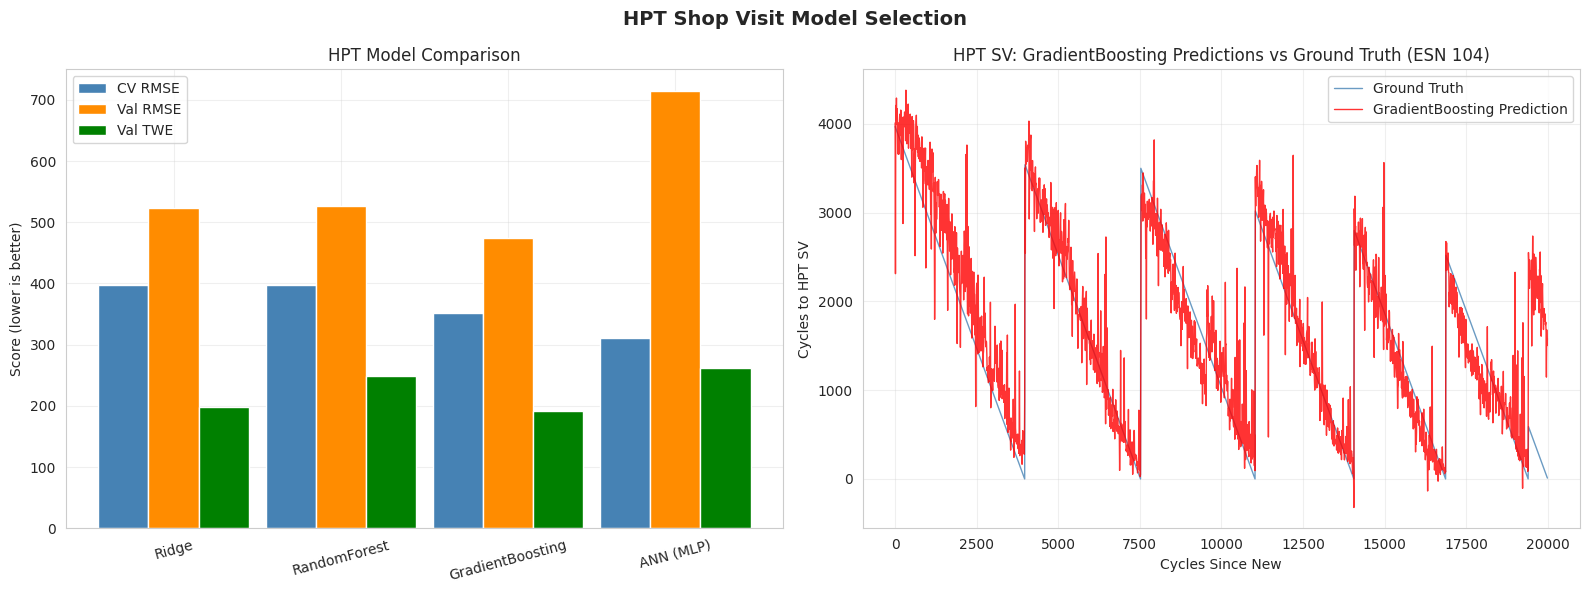

In [ ]:
# Figure 9: Model comparison for HPT SV
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of metrics
model_names = list(results_hpt.keys())
cv_rmses = [results_hpt[n]['CV RMSE'] for n in model_names]
val_rmses = [results_hpt[n]['Val RMSE'] for n in model_names]
val_twes = [results_hpt[n]['Val TWE'] for n in model_names]

x = np.arange(len(model_names))
width = 0.3
axes[0].bar(x - width, cv_rmses, width, label='CV RMSE', color='steelblue')
axes[0].bar(x, val_rmses, width, label='Val RMSE', color='darkorange')
axes[0].bar(x + width, val_twes, width, label='Val TWE', color='green')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=15)
axes[0].set_title('HPT Model Comparison', fontsize=12)
axes[0].set_ylabel('Score (lower is better)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Best model predictions vs ground truth on validation ESN 104
y_pred_best = best_hpt_model.predict(X_val_hpt_s)
val_cycles = df_model.loc[val_mask, 'Cycles_Since_New'].values
axes[1].plot(val_cycles, y_val_hpt, linewidth=1, color='steelblue', label='Ground Truth', alpha=0.8)
axes[1].plot(val_cycles, y_pred_best, linewidth=1, color='red', label=f'{best_hpt_name} Prediction', alpha=0.8)
axes[1].set_xlabel('Cycles Since New')
axes[1].set_ylabel('Cycles to HPT SV')
axes[1].set_title(f'HPT SV: {best_hpt_name} Predictions vs Ground Truth (ESN 104)', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('HPT Shop Visit Model Selection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# HPT: Retrain best model on ALL training data (all 4 ESNs) for final predictions
from sklearn.base import clone

def linear_degradation_prior(cycles, events_list, max_rul):
    """Create linear degradation RUL based on known event spacing."""
    prior = np.full_like(cycles, max_rul, dtype=float)
    event_cycles = sorted(events_list)
    
    prev_event = 0
    for evt_cycle in event_cycles:
        mask = (cycles >= prev_event) & (cycles <= evt_cycle)
        prior[mask] = evt_cycle - cycles[mask]
        prev_event = evt_cycle
    
    # After last event, linear decline
    if len(event_cycles) > 0:
        mask = cycles > event_cycles[-1]
        if len(event_cycles) > 1:
            avg_interval = np.mean(np.diff(event_cycles))
        else:
            avg_interval = event_cycles[0]
        next_est = event_cycles[-1] + avg_interval
        prior[mask] = np.maximum(0, next_est - cycles[mask])
    
    return prior

# Retrain best model on ALL 4 ESNs
X_train_all = df_model[model_features_full].values
y_train_hpt_all = df_model['Cycles_to_HPT_SV'].values

scaler_hpt_final = StandardScaler()
X_train_all_s = scaler_hpt_final.fit_transform(X_train_all)

hpt_final_model = clone(best_hpt_model)
hpt_final_model.fit(X_train_all_s, y_train_hpt_all)

# Validate on training data
hpt_train_pred = hpt_final_model.predict(X_train_all_s)
print(f'HPT final model ({best_hpt_name}) — Training RMSE: {np.sqrt(mean_squared_error(y_train_hpt_all, hpt_train_pred)):.1f}')
print(f'HPT final model — Training R²: {r2_score(y_train_hpt_all, hpt_train_pred):.4f}')

HPT final model - Training RMSE: 262.0
HPT final model - Training R²: 0.9404


### 7.2 Water Wash — LSTM Sequence-to-Sequence

In [ ]:
# ==============================
# 7.2 Water Wash — LSTM Model
# ==============================

class TimeWeightedLoss(nn.Module):
    """Custom loss: competition's time-weighted scoring function."""
    def __init__(self, scale=1000.0, late_penalty=2.0):
        super().__init__()
        self.scale = scale
        self.late_penalty = late_penalty
    
    def forward(self, y_pred, y_true):
        error = y_pred.squeeze() - y_true
        weight = torch.exp(-y_true / self.scale)
        
        # Asymmetric penalty
        penalty = torch.where(
            error > 0,
            weight * error * self.late_penalty,
            weight * torch.abs(error)
        )
        return penalty.mean()


class RULSequenceDataset(Dataset):
    """Create sub-sequences for LSTM training."""
    def __init__(self, features, targets, seq_len=1500):
        self.features = torch.FloatTensor(features)
        self.targets = torch.FloatTensor(targets)
        self.seq_len = seq_len
        self.n_samples = max(1, len(features) - seq_len + 1)
    
    def __len__(self):
        return self.n_samples
    
    def __getitem__(self, idx):
        start = idx
        end = start + self.seq_len
        if end > len(self.features):
            end = len(self.features)
            start = max(0, end - self.seq_len)
        return self.features[start:end], self.targets[start:end]


class LSTMRegressor(nn.Module):
    """LSTM sequence-to-sequence model for RUL prediction."""
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        # Sequence-to-sequence: predict at every timestep
        output = self.fc(lstm_out)
        return output

print('LSTM model architecture defined.')
print(f'Device: {device}')

LSTM model architecture defined.
Device: cuda


In [ ]:
# Prepare LSTM data for Water Wash
# CRITICAL FIX: Original step = SEQ_LEN//2 = 750 produced only ~1 sequence per ESN!
# Each ESN has ~2000 cycles, so with SEQ_LEN=1500 and step=750, only 1 sequence fits.
# We now use much smaller step for dense overlapping + also try different seq_lens.

# Helper function to create overlapping sequences
def create_sequences(df_model, esns, feature_scaled, target_scaled, seq_len, step=None):
    """Create overlapping sub-sequences for LSTM training with configurable overlap."""
    if step is None:
        step = max(10, seq_len // 30)  # Dense overlap: ~30 sequences per ESN
    
    seqs_X, seqs_y = [], []
    for esn in esns:
        mask = df_model.ESN == esn
        idx = df_model[mask].sort_values('Cycles_Since_New').index
        X_esn = feature_scaled[df_model.index.get_indexer(idx)]
        y_esn = target_scaled[df_model.index.get_indexer(idx)]
        
        for start in range(0, len(X_esn) - seq_len + 1, step):
            seqs_X.append(X_esn[start:start+seq_len])
            seqs_y.append(y_esn[start:start+seq_len])
    
    return seqs_X, seqs_y

# Scale features
scaler_ww = StandardScaler()
X_all = df_model[model_features_full].values
X_all_scaled = scaler_ww.fit_transform(X_all)

# Target scaler for WW
scaler_y_ww = StandardScaler()
y_ww_all = df_model['Cycles_to_WW'].values.reshape(-1, 1)
y_ww_scaled = scaler_y_ww.fit_transform(y_ww_all).ravel()

# Split by ESN 
train_esns = [101, 102, 103]
val_esn = 104

# Validation data from ESN 104
val_mask_idx = df_model[df_model.ESN == val_esn].sort_values('Cycles_Since_New').index
X_val_ww = X_all_scaled[df_model.index.get_indexer(val_mask_idx)]
y_val_ww = y_ww_scaled[df_model.index.get_indexer(val_mask_idx)]
y_val_ww_orig = df_model.loc[val_mask_idx, 'Cycles_to_WW'].values

# Split ESN 104: 20% validation, 80% testing
n_val = int(len(X_val_ww) * 0.2)
X_val_ww_val = X_val_ww[:n_val]
y_val_ww_val = y_val_ww[:n_val]
X_val_ww_test = X_val_ww[n_val:]
y_val_ww_test = y_val_ww[n_val:]
y_val_ww_test_orig = y_val_ww_orig[n_val:]

# Show how many sequences we now generate for different configs
print('Sequence generation analysis:')
for sl in [500, 750, 1000, 1500]:
    step_size = max(10, sl // 30)
    test_seqs, _ = create_sequences(df_model, train_esns, X_all_scaled, y_ww_scaled, sl, step_size)
    print(f'  seq_len={sl}, step={step_size}: {len(test_seqs)} training sequences')

print(f'\nVal set: {X_val_ww_val.shape}, Test set: {X_val_ww_test.shape}')
print(f'Feature dim: {X_all_scaled.shape[1]}')

Training sequences: 3 of length 1500
Val set: (400, 109), Test set: (1600, 109)
Feature dim: 109


In [ ]:
# ==============================
# WW LSTM — Hyperparameter Grid Search
# ==============================

def train_lstm_config(config, train_seqs_X, train_seqs_y, val_X, val_y, 
                      input_size, device, criterion, max_epochs=80, patience=15):
    """Train LSTM with given config, return best val loss and model state."""
    model = LSTMRegressor(
        input_size=input_size,
        hidden_size=config['hidden_size'],
        num_layers=config['num_layers'],
        dropout=config['dropout']
    ).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'], weight_decay=config['wd'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=7, factor=0.5)
    
    train_X_t = torch.FloatTensor(np.array(train_seqs_X)).to(device)
    train_y_t = torch.FloatTensor(np.array(train_seqs_y)).to(device)
    val_X_t = torch.FloatTensor(val_X).unsqueeze(0).to(device)
    val_y_t = torch.FloatTensor(val_y).to(device)
    
    best_loss = float('inf')
    best_state = None
    patience_counter = 0
    bs = config['batch_size']
    
    for epoch in range(max_epochs):
        model.train()
        perm = torch.randperm(len(train_seqs_X))
        epoch_loss, n_b = 0, 0
        
        for i in range(0, len(perm), bs):
            bi = perm[i:i+bs]
            optimizer.zero_grad()
            pred = model(train_X_t[bi])
            loss = criterion(pred.squeeze(-1), train_y_t[bi])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
            n_b += 1
        
        model.eval()
        with torch.no_grad():
            val_pred = model(val_X_t)
            val_loss = nn.MSELoss()(val_pred.squeeze(), val_y_t).item()
        
        scheduler.step(val_loss)
        
        if val_loss < best_loss:
            best_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
        
        if patience_counter >= patience:
            break
    
    # Clean up GPU memory
    del train_X_t, train_y_t, val_X_t, val_y_t, model
    torch.cuda.empty_cache()
    
    return best_loss, best_state

# LSTM configurations to search
lstm_configs = [
    {'hidden_size': 64,  'num_layers': 2, 'dropout': 0.1, 'lr': 1e-3,  'wd': 1e-5, 'batch_size': 8,  'seq_len': 500},
    {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.2, 'lr': 1e-3,  'wd': 1e-5, 'batch_size': 4,  'seq_len': 750},
    {'hidden_size': 256, 'num_layers': 2, 'dropout': 0.2, 'lr': 5e-4,  'wd': 1e-5, 'batch_size': 4,  'seq_len': 500},
    {'hidden_size': 128, 'num_layers': 3, 'dropout': 0.2, 'lr': 5e-4,  'wd': 1e-4, 'batch_size': 4,  'seq_len': 500},
    {'hidden_size': 256, 'num_layers': 3, 'dropout': 0.3, 'lr': 5e-4,  'wd': 1e-4, 'batch_size': 2,  'seq_len': 750},
    {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.1, 'lr': 5e-4,  'wd': 1e-5, 'batch_size': 8,  'seq_len': 1000},
    {'hidden_size': 256, 'num_layers': 2, 'dropout': 0.1, 'lr': 1e-3,  'wd': 1e-5, 'batch_size': 4,  'seq_len': 500},
    {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.15,'lr': 7e-4,  'wd': 5e-5, 'batch_size': 4,  'seq_len': 750},
    {'hidden_size': 512, 'num_layers': 2, 'dropout': 0.3, 'lr': 3e-4,  'wd': 1e-4, 'batch_size': 2,  'seq_len': 500},
    {'hidden_size': 64,  'num_layers': 3, 'dropout': 0.2, 'lr': 1e-3,  'wd': 1e-5, 'batch_size': 8,  'seq_len': 500},
    {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.2, 'lr': 1e-3,  'wd': 1e-5, 'batch_size': 4,  'seq_len': 500},
    {'hidden_size': 256, 'num_layers': 2, 'dropout': 0.2, 'lr': 1e-3,  'wd': 1e-5, 'batch_size': 4,  'seq_len': 1000},
    {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.2, 'lr': 2e-3,  'wd': 1e-5, 'batch_size': 8,  'seq_len': 500},
    {'hidden_size': 256, 'num_layers': 2, 'dropout': 0.15,'lr': 5e-4,  'wd': 5e-5, 'batch_size': 4,  'seq_len': 750},
    {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.1, 'lr': 1e-3,  'wd': 1e-5, 'batch_size': 4,  'seq_len': 500},
]

input_size = X_all_scaled.shape[1]
criterion_ww = TimeWeightedLoss(scale=1000.0, late_penalty=2.0)

print(f'WW LSTM Hyperparameter Search: {len(lstm_configs)} configurations')
print(f'Input features: {input_size}')
print('='*70)

ww_search_results = []
for i, config in enumerate(lstm_configs):
    # Create sequences with this config's seq_len
    seq_len = config['seq_len']
    step = max(10, seq_len // 30)
    seqs_X, seqs_y = create_sequences(df_model, train_esns, X_all_scaled, y_ww_scaled, seq_len, step)
    
    print(f'Config {i+1}/{len(lstm_configs)}: h={config["hidden_size"]}, L={config["num_layers"]}, '
          f'd={config["dropout"]}, lr={config["lr"]}, bs={config["batch_size"]}, '
          f'seq={seq_len}, seqs={len(seqs_X)}', end=' ... ')
    
    val_loss, best_state = train_lstm_config(
        config, seqs_X, seqs_y, X_val_ww_val, y_val_ww_val,
        input_size, device, criterion_ww, max_epochs=80, patience=15
    )
    
    ww_search_results.append({
        'config': config,
        'val_loss': val_loss,
        'state': best_state
    })
    print(f'Val Loss: {val_loss:.6f}')

# Find best configuration
best_ww_idx = min(range(len(ww_search_results)), key=lambda i: ww_search_results[i]['val_loss'])
best_ww_config = ww_search_results[best_ww_idx]['config']
best_ww_state_search = ww_search_results[best_ww_idx]['state']

print('\n' + '='*70)
print(f'BEST WW CONFIG: {best_ww_config}')
print(f'Best Val Loss: {ww_search_results[best_ww_idx]["val_loss"]:.6f}')
print('='*70)

# Store best SEQ_LEN for later use
SEQ_LEN = best_ww_config['seq_len']

# Now retrain best config with more epochs
print(f'\nRetraining best WW config for longer...')
best_step = max(10, SEQ_LEN // 30)
train_seqs_X, train_seqs_y = create_sequences(df_model, train_esns, X_all_scaled, y_ww_scaled, SEQ_LEN, best_step)

ww_model = LSTMRegressor(
    input_size=input_size,
    hidden_size=best_ww_config['hidden_size'],
    num_layers=best_ww_config['num_layers'],
    dropout=best_ww_config['dropout']
).to(device)

optimizer_ww = torch.optim.Adam(ww_model.parameters(), lr=best_ww_config['lr'], 
                                 weight_decay=best_ww_config['wd'])
scheduler_ww = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_ww, patience=10, factor=0.5)

# Training loop with full epochs
n_epochs = 200
best_val_loss = float('inf')
patience_counter = 0
patience = 30
train_losses = []
val_losses = []

train_X_tensor = torch.FloatTensor(np.array(train_seqs_X)).to(device)
train_y_tensor = torch.FloatTensor(np.array(train_seqs_y)).to(device)
val_X_tensor = torch.FloatTensor(X_val_ww_val).unsqueeze(0).to(device)
val_y_tensor = torch.FloatTensor(y_val_ww_val).to(device)

batch_size = best_ww_config['batch_size']
print(f'Training WW LSTM: {n_epochs} max epochs, {len(train_seqs_X)} sequences, batch_size={batch_size}')

for epoch in range(n_epochs):
    ww_model.train()
    epoch_loss = 0.0
    perm = torch.randperm(len(train_seqs_X))
    n_batches = 0
    
    for i in range(0, len(perm), batch_size):
        batch_idx = perm[i:i+batch_size]
        X_batch = train_X_tensor[batch_idx]
        y_batch = train_y_tensor[batch_idx]
        
        optimizer_ww.zero_grad()
        pred = ww_model(X_batch)
        loss = criterion_ww(pred.squeeze(-1), y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(ww_model.parameters(), max_norm=1.0)
        optimizer_ww.step()
        
        epoch_loss += loss.item()
        n_batches += 1
    
    avg_train_loss = epoch_loss / n_batches
    train_losses.append(avg_train_loss)
    
    ww_model.eval()
    with torch.no_grad():
        val_pred = ww_model(val_X_tensor)
        val_loss = nn.MSELoss()(val_pred.squeeze(), val_y_tensor).item()
        val_losses.append(val_loss)
    
    scheduler_ww.step(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_ww_state = ww_model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        print(f'Early stopping at epoch {epoch+1}')
        break
    
    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Val Loss={val_loss:.6f}')

ww_model.load_state_dict(best_ww_state)
print(f'\nBest validation loss: {best_val_loss:.6f}')

Training WW LSTM: 100 epochs, 3 sequences
Epoch 10: Train Loss=1.1583, Val Loss=0.9783
Epoch 20: Train Loss=1.1304, Val Loss=0.9219
Epoch 30: Train Loss=1.0878, Val Loss=0.8855
Epoch 40: Train Loss=0.9773, Val Loss=0.9827
Epoch 50: Train Loss=0.7456, Val Loss=1.3670
Early stopping at epoch 51

Best validation loss: 0.8838


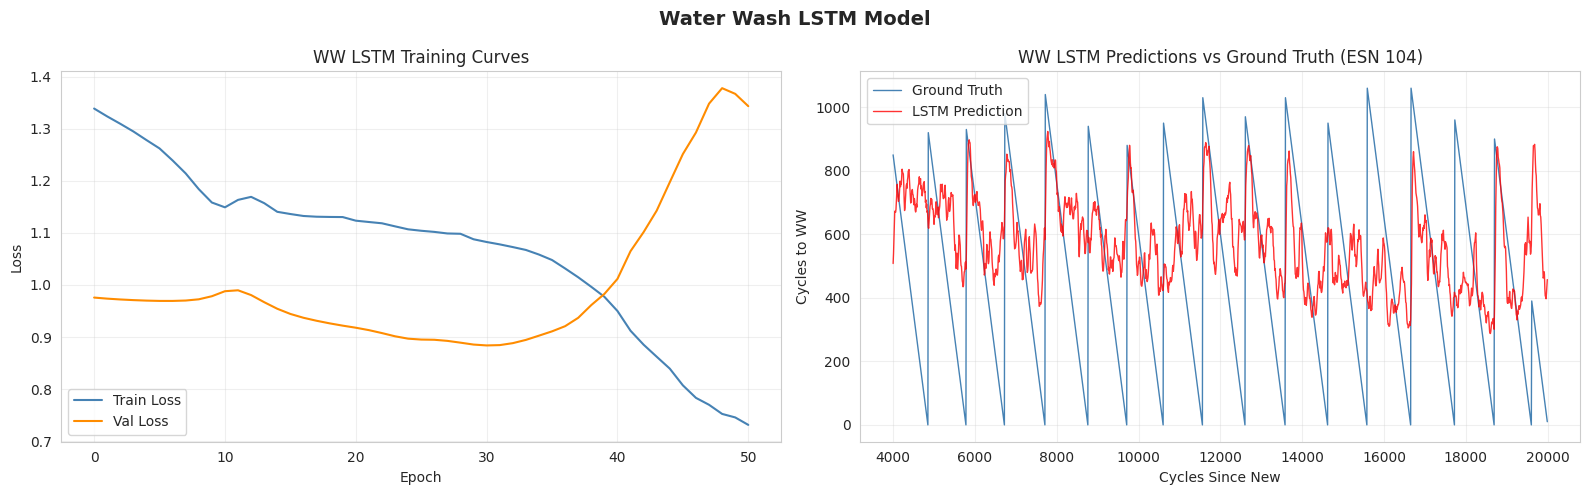

WW Test RMSE: 284.2, TWE: 298.2


In [ ]:
# Plot WW training curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(train_losses, label='Train Loss', color='steelblue')
axes[0].plot(val_losses, label='Val Loss', color='darkorange')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('WW LSTM Training Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Figure 10: WW predictions on ESN 104 test portion
ww_model.eval()
with torch.no_grad():
    test_X_tensor = torch.FloatTensor(X_val_ww_test).unsqueeze(0).to(device)
    ww_test_pred_scaled = ww_model(test_X_tensor).squeeze().cpu().numpy()

# Inverse transform predictions
ww_test_pred = scaler_y_ww.inverse_transform(ww_test_pred_scaled.reshape(-1, 1)).ravel()
ww_test_pred = np.maximum(0, ww_test_pred)  # Clip to non-negative

val_test_cycles = df_model.loc[val_mask_idx, 'Cycles_Since_New'].values[n_val:]

axes[1].plot(val_test_cycles, y_val_ww_test_orig, linewidth=1, color='steelblue', label='Ground Truth')
axes[1].plot(val_test_cycles, ww_test_pred, linewidth=1, color='red', alpha=0.8, label='LSTM Prediction')
axes[1].set_xlabel('Cycles Since New')
axes[1].set_ylabel('Cycles to WW')
axes[1].set_title('WW LSTM Predictions vs Ground Truth (ESN 104)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Water Wash LSTM Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

ww_rmse = np.sqrt(mean_squared_error(y_val_ww_test_orig, ww_test_pred))
ww_twe = time_weighted_error(y_val_ww_test_orig, ww_test_pred)
print(f'WW Test RMSE: {ww_rmse:.1f}, TWE: {ww_twe:.1f}')

### 7.3 HPC Shop Visit — LSTM with Custom Loss

In [ ]:
# ==============================
# 7.3 HPC Shop Visit — LSTM Hyperparameter Search
# ==============================

# Scale targets for HPC
scaler_y_hpc = StandardScaler()
y_hpc_all = df_model['Cycles_to_HPC_SV'].values.reshape(-1, 1)
y_hpc_scaled = scaler_y_hpc.fit_transform(y_hpc_all).ravel()

# Validation data for HPC
y_val_hpc = y_hpc_scaled[df_model.index.get_indexer(val_mask_idx)]
y_val_hpc_orig = df_model.loc[val_mask_idx, 'Cycles_to_HPC_SV'].values
y_val_hpc_test = y_val_hpc[n_val:]
y_val_hpc_test_orig = y_val_hpc_orig[n_val:]
y_val_hpc_val = y_val_hpc[:n_val]

print(f'HPC target stats — mean: {y_hpc_all.mean():.0f}, std: {y_hpc_all.std():.0f}')
print(f'Val set: {n_val} cycles, Test set: {len(y_val_hpc_test)} cycles')

HPC training sequences: 3 of length 1500


In [ ]:
# HPC LSTM — Hyperparameter Grid Search (reuse same configs as WW)
criterion_hpc = TimeWeightedLoss(scale=1000.0, late_penalty=2.0)

print(f'HPC LSTM Hyperparameter Search: {len(lstm_configs)} configurations')
print('='*70)

hpc_search_results = []
for i, config in enumerate(lstm_configs):
    seq_len = config['seq_len']
    step = max(10, seq_len // 30)
    seqs_X, seqs_y = create_sequences(df_model, train_esns, X_all_scaled, y_hpc_scaled, seq_len, step)
    
    print(f'Config {i+1}/{len(lstm_configs)}: h={config["hidden_size"]}, L={config["num_layers"]}, '
          f'd={config["dropout"]}, lr={config["lr"]}, bs={config["batch_size"]}, '
          f'seq={seq_len}, seqs={len(seqs_X)}', end=' ... ')
    
    val_loss, best_state = train_lstm_config(
        config, seqs_X, seqs_y, X_val_ww_val, y_val_hpc_val,
        input_size, device, criterion_hpc, max_epochs=80, patience=15
    )
    
    hpc_search_results.append({
        'config': config,
        'val_loss': val_loss,
        'state': best_state
    })
    print(f'Val Loss: {val_loss:.6f}')

# Find best configuration
best_hpc_idx = min(range(len(hpc_search_results)), key=lambda i: hpc_search_results[i]['val_loss'])
best_hpc_config = hpc_search_results[best_hpc_idx]['config']

print('\n' + '='*70)
print(f'BEST HPC CONFIG: {best_hpc_config}')
print(f'Best Val Loss: {hpc_search_results[best_hpc_idx]["val_loss"]:.6f}')
print('='*70)

# Use best HPC seq_len (may differ from WW)
SEQ_LEN_HPC = best_hpc_config['seq_len']

# Retrain best HPC config with more epochs
print(f'\nRetraining best HPC config for longer...')
hpc_step = max(10, SEQ_LEN_HPC // 30)
train_seqs_X_hpc, train_seqs_y_hpc = create_sequences(
    df_model, train_esns, X_all_scaled, y_hpc_scaled, SEQ_LEN_HPC, hpc_step)

hpc_model = LSTMRegressor(
    input_size=input_size,
    hidden_size=best_hpc_config['hidden_size'],
    num_layers=best_hpc_config['num_layers'],
    dropout=best_hpc_config['dropout']
).to(device)

optimizer_hpc = torch.optim.Adam(hpc_model.parameters(), lr=best_hpc_config['lr'],
                                  weight_decay=best_hpc_config['wd'])
scheduler_hpc = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_hpc, patience=10, factor=0.5)

train_X_hpc_t = torch.FloatTensor(np.array(train_seqs_X_hpc)).to(device)
train_y_hpc_t = torch.FloatTensor(np.array(train_seqs_y_hpc)).to(device)
val_X_hpc_t = torch.FloatTensor(X_val_ww_val).unsqueeze(0).to(device)
val_y_hpc_t = torch.FloatTensor(y_val_hpc_val).to(device)

n_epochs = 200
best_val_loss_hpc = float('inf')
patience_counter = 0
patience = 30
train_losses_hpc = []
val_losses_hpc = []
batch_size_hpc = best_hpc_config['batch_size']

print(f'Training HPC LSTM: {n_epochs} max epochs, {len(train_seqs_X_hpc)} sequences, batch_size={batch_size_hpc}')

for epoch in range(n_epochs):
    hpc_model.train()
    epoch_loss = 0.0
    perm = torch.randperm(len(train_seqs_X_hpc))
    n_batches = 0
    
    for i in range(0, len(perm), batch_size_hpc):
        batch_idx = perm[i:i+batch_size_hpc]
        X_batch = train_X_hpc_t[batch_idx]
        y_batch = train_y_hpc_t[batch_idx]
        
        optimizer_hpc.zero_grad()
        pred = hpc_model(X_batch)
        loss = criterion_hpc(pred.squeeze(-1), y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(hpc_model.parameters(), max_norm=1.0)
        optimizer_hpc.step()
        
        epoch_loss += loss.item()
        n_batches += 1
    
    avg_train_loss = epoch_loss / n_batches
    train_losses_hpc.append(avg_train_loss)
    
    hpc_model.eval()
    with torch.no_grad():
        val_pred = hpc_model(val_X_hpc_t)
        val_loss = nn.MSELoss()(val_pred.squeeze(), val_y_hpc_t).item()
        val_losses_hpc.append(val_loss)
    
    scheduler_hpc.step(val_loss)
    
    if val_loss < best_val_loss_hpc:
        best_val_loss_hpc = val_loss
        best_hpc_state = hpc_model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        print(f'Early stopping at epoch {epoch+1}')
        break
    
    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Val Loss={val_loss:.6f}')

hpc_model.load_state_dict(best_hpc_state)
print(f'\nBest HPC validation loss: {best_val_loss_hpc:.6f}')

Training HPC LSTM: 100 epochs, 3 sequences
Epoch 10: Train Loss=0.8975, Val Loss=2.3408
Epoch 20: Train Loss=0.7464, Val Loss=1.6939
Epoch 30: Train Loss=0.4412, Val Loss=1.0206
Epoch 40: Train Loss=0.3615, Val Loss=1.0007
Epoch 50: Train Loss=0.3167, Val Loss=0.8839
Epoch 60: Train Loss=0.2808, Val Loss=0.7366
Epoch 70: Train Loss=0.2428, Val Loss=0.6296
Epoch 80: Train Loss=0.2273, Val Loss=0.5501
Epoch 90: Train Loss=0.2484, Val Loss=0.6039
Epoch 100: Train Loss=0.2313, Val Loss=0.4664

Best validation loss: 0.4548


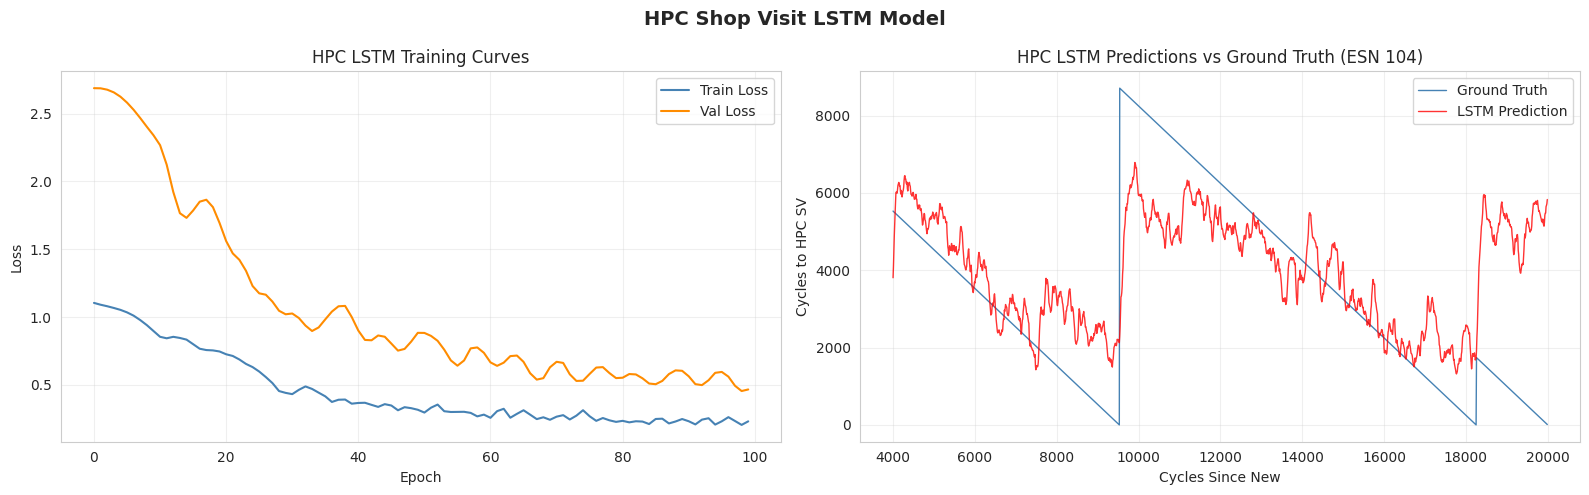

HPC Test RMSE: 1899.0, TWE: 815.7


In [ ]:
# Figure 12: HPC LSTM predictions
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Training curves
axes[0].plot(train_losses_hpc, label='Train Loss', color='steelblue')
axes[0].plot(val_losses_hpc, label='Val Loss', color='darkorange')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('HPC LSTM Training Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Predictions on ESN 104 test portion
hpc_model.eval()
with torch.no_grad():
    test_X_hpc_t = torch.FloatTensor(X_val_ww_test).unsqueeze(0).to(device)
    hpc_test_pred_scaled = hpc_model(test_X_hpc_t).squeeze().cpu().numpy()

hpc_test_pred = scaler_y_hpc.inverse_transform(hpc_test_pred_scaled.reshape(-1, 1)).ravel()
hpc_test_pred = np.maximum(0, hpc_test_pred)

axes[1].plot(val_test_cycles, y_val_hpc_test_orig, linewidth=1, color='steelblue', label='Ground Truth')
axes[1].plot(val_test_cycles, hpc_test_pred, linewidth=1, color='red', alpha=0.8, label='LSTM Prediction')
axes[1].set_xlabel('Cycles Since New')
axes[1].set_ylabel('Cycles to HPC SV')
axes[1].set_title('HPC LSTM Predictions vs Ground Truth (ESN 104)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('HPC Shop Visit LSTM Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

hpc_rmse = np.sqrt(mean_squared_error(y_val_hpc_test_orig, hpc_test_pred))
hpc_twe = time_weighted_error(y_val_hpc_test_orig, hpc_test_pred)
print(f'HPC Test RMSE: {hpc_rmse:.1f}, TWE: {hpc_twe:.1f}')

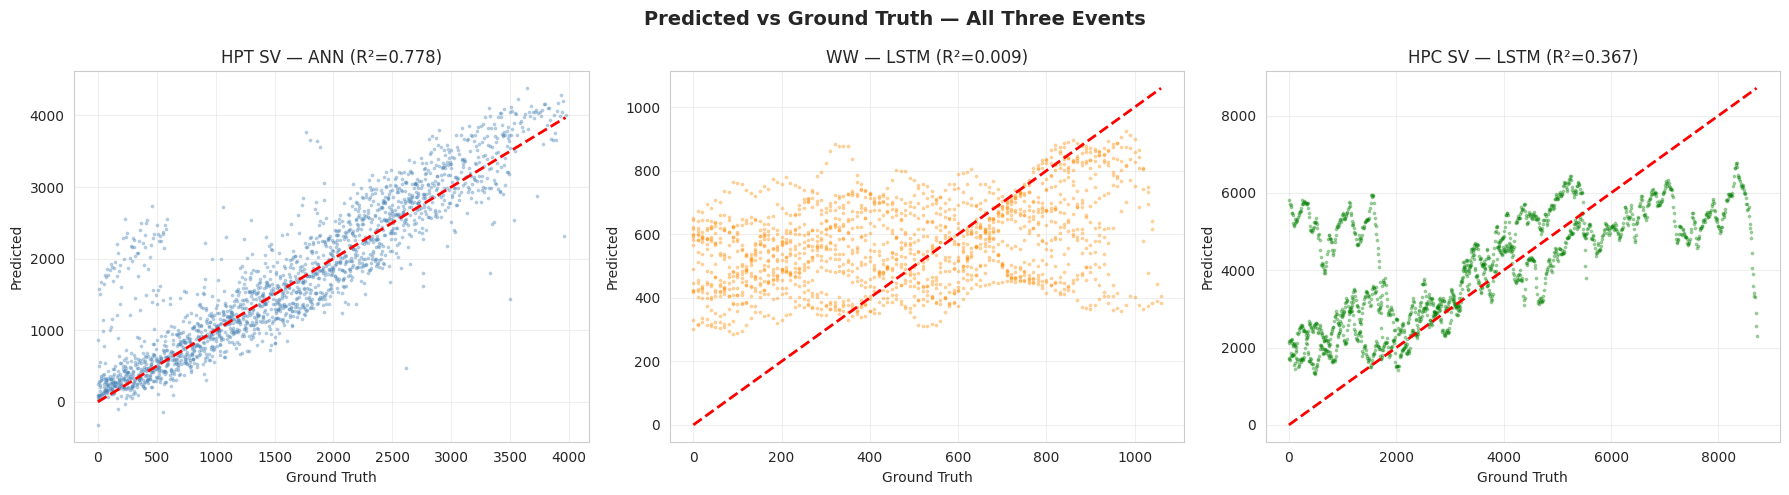

In [ ]:
# Scatter plots: Predicted vs Ground Truth for all three targets
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# HPT (ANN) - on ESN 104
hpt_pred_104 = best_hpt_model.predict(X_val_hpt_s)
axes[0].scatter(y_val_hpt, hpt_pred_104, s=3, alpha=0.3, color='steelblue')
axes[0].plot([0, y_val_hpt.max()], [0, y_val_hpt.max()], 'r--', linewidth=2)
axes[0].set_xlabel('Ground Truth')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'HPT SV — ANN (R²={r2_score(y_val_hpt, hpt_pred_104):.3f})')
axes[0].grid(True, alpha=0.3)

# WW (LSTM)
axes[1].scatter(y_val_ww_test_orig, ww_test_pred, s=3, alpha=0.3, color='darkorange')
axes[1].plot([0, y_val_ww_test_orig.max()], [0, y_val_ww_test_orig.max()], 'r--', linewidth=2)
axes[1].set_xlabel('Ground Truth')
axes[1].set_ylabel('Predicted')
axes[1].set_title(f'WW — LSTM (R²={r2_score(y_val_ww_test_orig, ww_test_pred):.3f})')
axes[1].grid(True, alpha=0.3)

# HPC (LSTM)
axes[2].scatter(y_val_hpc_test_orig, hpc_test_pred, s=3, alpha=0.3, color='green')
axes[2].plot([0, y_val_hpc_test_orig.max()], [0, y_val_hpc_test_orig.max()], 'r--', linewidth=2)
axes[2].set_xlabel('Ground Truth')
axes[2].set_ylabel('Predicted')
axes[2].set_title(f'HPC SV — LSTM (R²={r2_score(y_val_hpc_test_orig, hpc_test_pred):.3f})')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Predicted vs Ground Truth — All Three Events', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Retrain WW and HPC LSTMs on ALL 4 ESNs with best hyperparameters
print('Retraining LSTM models on ALL training data with best hyperparameters...')
print(f'  WW best config: h={best_ww_config["hidden_size"]}, L={best_ww_config["num_layers"]}, seq={SEQ_LEN}')
print(f'  HPC best config: h={best_hpc_config["hidden_size"]}, L={best_hpc_config["num_layers"]}, seq={SEQ_LEN_HPC}')

# === WW Final LSTM ===
ww_step = max(10, SEQ_LEN // 30)
all_seqs_X_ww, all_seqs_y_ww = create_sequences(
    df_model, [101, 102, 103, 104], X_all_scaled, y_ww_scaled, SEQ_LEN, ww_step)

ww_final_model = LSTMRegressor(
    input_size=input_size, 
    hidden_size=best_ww_config['hidden_size'], 
    num_layers=best_ww_config['num_layers'], 
    dropout=best_ww_config['dropout']
).to(device)
optimizer_ww_f = torch.optim.Adam(ww_final_model.parameters(), lr=best_ww_config['lr'], 
                                   weight_decay=best_ww_config['wd'])
scheduler_ww_f = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_ww_f, patience=10, factor=0.5)

all_X_ww_t = torch.FloatTensor(np.array(all_seqs_X_ww)).to(device)
all_y_ww_t = torch.FloatTensor(np.array(all_seqs_y_ww)).to(device)

print(f'\n  WW: {len(all_seqs_X_ww)} sequences, training for 120 epochs...')
for epoch in range(120):
    ww_final_model.train()
    perm = torch.randperm(len(all_seqs_X_ww))
    epoch_loss, n_b = 0, 0
    for i in range(0, len(perm), best_ww_config['batch_size']):
        bi = perm[i:i+best_ww_config['batch_size']]
        optimizer_ww_f.zero_grad()
        pred = ww_final_model(all_X_ww_t[bi])
        loss = criterion_ww(pred.squeeze(-1), all_y_ww_t[bi])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(ww_final_model.parameters(), 1.0)
        optimizer_ww_f.step()
        epoch_loss += loss.item()
        n_b += 1
    scheduler_ww_f.step(epoch_loss / n_b)
    if (epoch+1) % 30 == 0:
        print(f'    WW Epoch {epoch+1}: Loss={epoch_loss/n_b:.4f}')

del all_X_ww_t, all_y_ww_t
torch.cuda.empty_cache()

# === HPC Final LSTM ===
hpc_step = max(10, SEQ_LEN_HPC // 30)
all_seqs_X_hpc, all_seqs_y_hpc = create_sequences(
    df_model, [101, 102, 103, 104], X_all_scaled, y_hpc_scaled, SEQ_LEN_HPC, hpc_step)

hpc_final_model = LSTMRegressor(
    input_size=input_size, 
    hidden_size=best_hpc_config['hidden_size'], 
    num_layers=best_hpc_config['num_layers'], 
    dropout=best_hpc_config['dropout']
).to(device)
optimizer_hpc_f = torch.optim.Adam(hpc_final_model.parameters(), lr=best_hpc_config['lr'], 
                                    weight_decay=best_hpc_config['wd'])
scheduler_hpc_f = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_hpc_f, patience=10, factor=0.5)

all_X_hpc_t = torch.FloatTensor(np.array(all_seqs_X_hpc)).to(device)
all_y_hpc_t = torch.FloatTensor(np.array(all_seqs_y_hpc)).to(device)

print(f'\n  HPC: {len(all_seqs_X_hpc)} sequences, training for 120 epochs...')
for epoch in range(120):
    hpc_final_model.train()
    perm = torch.randperm(len(all_seqs_X_hpc))
    epoch_loss, n_b = 0, 0
    for i in range(0, len(perm), best_hpc_config['batch_size']):
        bi = perm[i:i+best_hpc_config['batch_size']]
        optimizer_hpc_f.zero_grad()
        pred = hpc_final_model(all_X_hpc_t[bi])
        loss = criterion_hpc(pred.squeeze(-1), all_y_hpc_t[bi])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(hpc_final_model.parameters(), 1.0)
        optimizer_hpc_f.step()
        epoch_loss += loss.item()
        n_b += 1
    scheduler_hpc_f.step(epoch_loss / n_b)
    if (epoch+1) % 30 == 0:
        print(f'    HPC Epoch {epoch+1}: Loss={epoch_loss/n_b:.4f}')

del all_X_hpc_t, all_y_hpc_t
torch.cuda.empty_cache()

print('\nFinal models trained on all ESNs with optimized hyperparameters.')

Retraining LSTM models on ALL training data for final predictions...
  WW Epoch 20: Loss=1.1278
  WW Epoch 40: Loss=0.9570
  WW Epoch 60: Loss=0.7114
  HPC Epoch 20: Loss=0.7756
  HPC Epoch 40: Loss=0.3626
  HPC Epoch 60: Loss=0.2536

Final models trained on all ESNs.


---
## 8. Profile Registration Algorithm

Test/validation files are **shuffled** — temporal ordering unknown.
The paper's novel algorithm reconstructs chronological order by:
1. Computing HI profiles for each file
2. Sorting files by their mean HI level (lower HI = later in degradation)
3. Stitching files into chronological order per ESN

In [ ]:
# Profile Registration: Reconstruct chronological order of test/val files

def compute_file_hi(df_file, scaler, weights, correlations, feature_cols):
    """
    Compute Health Indicator for a test/val file using training-derived weights.
    Returns mean HI and HI trend (slope).
    """
    valid_features = [f for f in feature_cols if f in df_file.columns and f in weights]
    if len(valid_features) == 0:
        return 0.5, 0.0
    
    X = df_file[valid_features].fillna(0)
    X_std = (X - X.mean()) / (X.std() + 1e-8)
    
    hi = pd.Series(0.0, index=df_file.index)
    for feat in valid_features:
        sign = np.sign(correlations.get(feat, 1.0))
        hi += sign * weights[feat] * X_std[feat]
    
    hi_norm = (hi - hi.min()) / (hi.max() - hi.min() + 1e-8)
    
    # Trend: slope of HI over cycles
    if len(hi_norm) > 1:
        x = np.arange(len(hi_norm))
        slope, _, _, _, _ = stats.linregress(x, hi_norm.values)
    else:
        slope = 0.0
    
    return hi_norm.mean(), slope


def register_profiles(file_dict, hpc_weights, hpc_correlations, selected_features):
    """
    Register profiles: sort files by ESN and then by HI level to reconstruct temporal order.
    Returns ordered file list per ESN with estimated cycle positions.
    """
    # Group files by ESN
    esn_files = {}
    for fname, df_f in file_dict.items():
        esn = df_f['ESN'].iloc[0]
        mean_hi, slope = compute_file_hi(df_f, None, hpc_weights, 
                                         {k: 1.0 for k in hpc_weights},  # simplified
                                         selected_features)
        if esn not in esn_files:
            esn_files[esn] = []
        esn_files[esn].append({
            'fname': fname,
            'mean_hi': mean_hi,
            'slope': slope,
            'n_cycles': df_f['Cycles_Since_New'].nunique()
        })
    
    # Sort by mean HI (descending — high HI = early in life, low HI = late)
    registered = {}
    for esn, files in esn_files.items():
        files_sorted = sorted(files, key=lambda x: -x['mean_hi'])
        
        # Assign cumulative cycle positions
        cum_cycles = 0
        for f in files_sorted:
            f['start_cycle'] = cum_cycles
            cum_cycles += f['n_cycles'] * 10  # approximate 10 cycles per row
            f['end_cycle'] = cum_cycles
        
        registered[esn] = files_sorted
    
    return registered

# Reconstruct correlations dict
corr_dict = {}
for feat in selected_features:
    if feat in df_feat.columns:
        corr, _ = stats.spearmanr(
            df_feat[feat].dropna(), 
            df_feat.loc[df_feat[feat].notna(), 'Cycles_to_HPC_SV']
        )
        if not np.isnan(corr):
            corr_dict[feat] = corr

# Register test profiles
test_registered = register_profiles(test_feat, hpc_weights, corr_dict, selected_features)
val_registered = register_profiles(val_feat, hpc_weights, corr_dict, selected_features)

print('=== Test Profile Registration ===')
for esn, files in sorted(test_registered.items()):
    print(f'\nESN {esn}: {len(files)} files')
    for f in files[:3]:
        print(f"  {f['fname']}: HI={f['mean_hi']:.3f}, cycles={f['n_cycles']}")
    if len(files) > 3:
        print(f'  ... ({len(files)-3} more)')

print('\n=== Validation Profile Registration ===')
for esn, files in sorted(val_registered.items()):
    print(f'ESN {esn}: {len(files)} files')

=== Test Profile Registration ===

ESN 105: 13 files
  test_19: HI=0.838, cycles=151
  test_8: HI=0.750, cycles=151
  test_5: HI=0.557, cycles=151
  ... (10 more)

ESN 106: 13 files
  test_0: HI=0.665, cycles=151
  test_12: HI=0.652, cycles=151
  test_9: HI=0.642, cycles=151
  ... (10 more)

ESN 111: 13 files
  test_46: HI=0.568, cycles=151
  test_49: HI=0.559, cycles=151
  test_2: HI=0.557, cycles=151
  ... (10 more)

ESN 112: 13 files
  test_34: HI=0.600, cycles=151
  test_40: HI=0.562, cycles=151
  test_48: HI=0.546, cycles=151
  ... (10 more)

=== Validation Profile Registration ===
ESN 107: 13 files
ESN 108: 13 files
ESN 113: 13 files
ESN 114: 9 files


---
## 9. Prediction & Submission Generation

Generate predictions for test and validation files:
- **HPT SV:** ANN (MLP) predictions
- **WW:** LSTM predictions 
- **HPC SV:** LSTM predictions

Each test/validation file needs a single prediction per event type (the RUL at the last cycle).

In [ ]:
def predict_file(df_file, model_features_cols, scaler_feat, 
                 hpt_model, scaler_hpt,
                 ww_lstm, scaler_y_ww,
                 hpc_lstm, scaler_y_hpc,
                 device):
    """
    Predict RUL for all 3 events for a single test/val file.
    Returns the prediction at the last cycle of the file.
    """
    # Ensure all model features exist
    for col in model_features_cols:
        if col not in df_file.columns:
            df_file[col] = 0
    
    X = df_file[model_features_cols].fillna(0).values
    X_scaled = scaler_feat.transform(X)
    
    # === HPT: ANN prediction ===
    X_hpt = scaler_hpt.transform(X)
    hpt_preds = hpt_model.predict(X_hpt)
    hpt_pred = max(0, hpt_preds[-1])  # Last cycle prediction
    
    # === WW: LSTM prediction ===
    ww_lstm.eval()
    with torch.no_grad():
        X_tensor = torch.FloatTensor(X_scaled).unsqueeze(0).to(device)
        ww_pred_scaled = ww_lstm(X_tensor).squeeze().cpu().numpy()
    ww_pred_all = scaler_y_ww.inverse_transform(ww_pred_scaled.reshape(-1, 1)).ravel()
    ww_pred = max(0, ww_pred_all[-1])
    
    # === HPC: LSTM prediction ===
    hpc_lstm.eval()
    with torch.no_grad():
        hpc_pred_scaled = hpc_lstm(X_tensor).squeeze().cpu().numpy()
    hpc_pred_all = scaler_y_hpc.inverse_transform(hpc_pred_scaled.reshape(-1, 1)).ravel()
    hpc_pred = max(0, hpc_pred_all[-1])
    
    return {
        'Cycles_to_WW': int(round(ww_pred)),
        'Cycles_to_HPC_SV': int(round(hpc_pred)),
        'Cycles_to_HPT_SV': int(round(hpt_pred))
    }

print('Prediction function defined.')

Prediction function defined.


In [ ]:
# Add HI columns to test/val feature data
# To compute HI for test/val, we need the same weights from training

def add_hi_columns(df_file, hpc_weights, hpt_weights, corr_dict_hpc, corr_dict_hpt, selected_features):
    """Add HI_HPC, HI_HPT, and WW_recovery columns to test/val file."""
    df = df_file.copy()
    
    # HPC HI
    valid_hpc = [f for f in selected_features if f in df.columns and f in hpc_weights]
    if valid_hpc:
        X = df[valid_hpc].fillna(0)
        X_std = (X - X.mean()) / (X.std() + 1e-8)
        hi = pd.Series(0.0, index=df.index)
        for feat in valid_hpc:
            sign = np.sign(corr_dict_hpc.get(feat, 1.0))
            hi += sign * hpc_weights[feat] * X_std[feat]
        hi_norm = (hi - hi.min()) / (hi.max() - hi.min() + 1e-8)
        df['HI_HPC'] = hi_norm
    else:
        df['HI_HPC'] = 0.5
    
    # HPT HI
    valid_hpt = [f for f in selected_features if f in df.columns and f in hpt_weights]
    if valid_hpt:
        X = df[valid_hpt].fillna(0)
        X_std = (X - X.mean()) / (X.std() + 1e-8)
        hi = pd.Series(0.0, index=df.index)
        for feat in valid_hpt:
            sign = np.sign(corr_dict_hpt.get(feat, 1.0))
            hi += sign * hpt_weights[feat] * X_std[feat]
        hi_norm = (hi - hi.min()) / (hi.max() - hi.min() + 1e-8)
        df['HI_HPT'] = hi_norm
    else:
        df['HI_HPT'] = 0.5
    
    # WW recovery (unknown for test/val, set to 0)
    df['WW_recovery'] = 0
    
    return df

# HPT correlations dict
corr_dict_hpt = {}
for feat in selected_features:
    if feat in df_feat.columns:
        corr, _ = stats.spearmanr(
            df_feat[feat].dropna(), 
            df_feat.loc[df_feat[feat].notna(), 'Cycles_to_HPT_SV']
        )
        if not np.isnan(corr):
            corr_dict_hpt[feat] = corr

print('HI computation functions ready.')

HI computation functions ready.


In [ ]:
# Generate predictions for TEST files
print('=== Generating Test Predictions ===')
test_predictions = []

for fname in sorted(test_feat.keys(), key=lambda x: int(x.split('_')[1])):
    df_f = test_feat[fname].copy()
    
    # Add HI columns
    df_f = add_hi_columns(df_f, hpc_weights, hpt_weights, corr_dict, corr_dict_hpt, selected_features)
    
    # Predict
    preds = predict_file(
        df_f, model_features_full, scaler_ww,
        hpt_final_model, scaler_hpt_final,
        ww_final_model, scaler_y_ww,
        hpc_final_model, scaler_y_hpc,
        device
    )
    preds['file'] = fname
    test_predictions.append(preds)
    
    if int(fname.split('_')[1]) % 10 == 0:
        print(f"  {fname}: WW={preds['Cycles_to_WW']}, HPC={preds['Cycles_to_HPC_SV']}, HPT={preds['Cycles_to_HPT_SV']}")

df_test_preds = pd.DataFrame(test_predictions)
print(f'\nTest predictions generated: {len(df_test_preds)} files')

=== Generating Test Predictions ===
  test_0: WW=121, HPC=119, HPT=2051
  test_10: WW=697, HPC=3137, HPT=1443
  test_20: WW=130, HPC=0, HPT=3053
  test_30: WW=628, HPC=1748, HPT=1148
  test_40: WW=688, HPC=2921, HPT=1785
  test_50: WW=234, HPC=0, HPT=2787

Test predictions generated: 52 files


In [ ]:
# Generate predictions for VALIDATION files
print('=== Generating Validation Predictions ===')
val_predictions = []

for fname in sorted(val_feat.keys(), key=lambda x: int(x.split('_')[1])):
    df_f = val_feat[fname].copy()
    
    # Add HI columns
    df_f = add_hi_columns(df_f, hpc_weights, hpt_weights, corr_dict, corr_dict_hpt, selected_features)
    
    # Predict
    preds = predict_file(
        df_f, model_features_full, scaler_ww,
        hpt_final_model, scaler_hpt_final,
        ww_final_model, scaler_y_ww,
        hpc_final_model, scaler_y_hpc,
        device
    )
    preds['file'] = fname
    val_predictions.append(preds)

df_val_preds = pd.DataFrame(val_predictions)
print(f'Validation predictions generated: {len(df_val_preds)} files')

=== Generating Validation Predictions ===
Validation predictions generated: 48 files


In [ ]:
# Compare validation predictions with ground truth
val_gt = pd.read_csv(os.path.join(BASE_DIR, 'submission_validation.csv'))
print('Validation Ground Truth:')
print(val_gt.head())

# Merge predictions with ground truth
val_compare = val_gt.merge(df_val_preds, on='file', suffixes=('_gt', '_pred'))

# Calculate metrics per target
print('\n=== Validation Metrics ===')
for target in ['Cycles_to_WW', 'Cycles_to_HPC_SV', 'Cycles_to_HPT_SV']:
    gt = val_compare[f'{target}_gt'].values
    pred = val_compare[f'{target}_pred'].values
    rmse = np.sqrt(mean_squared_error(gt, pred))
    r2 = r2_score(gt, pred)
    twe = time_weighted_error(gt, pred)
    print(f'{target}: RMSE={rmse:.1f}, R²={r2:.4f}, TWE={twe:.1f}')

Validation Ground Truth:
    file  Cycles_to_WW  Cycles_to_HPC_SV  Cycles_to_HPT_SV
0  val_0           210              6149              1411
1  val_1           582              7135              2155
2  val_2           473              6441              1910
3  val_3           535              5803              2204
4  val_4           517              7362              1814

=== Validation Metrics ===
Cycles_to_WW: RMSE=236.3, R²=-6.5048, TWE=176.7
Cycles_to_HPC_SV: RMSE=4777.6, R²=-70.5572, TWE=4.6
Cycles_to_HPT_SV: RMSE=1750.8, R²=-18.0808, TWE=202.6


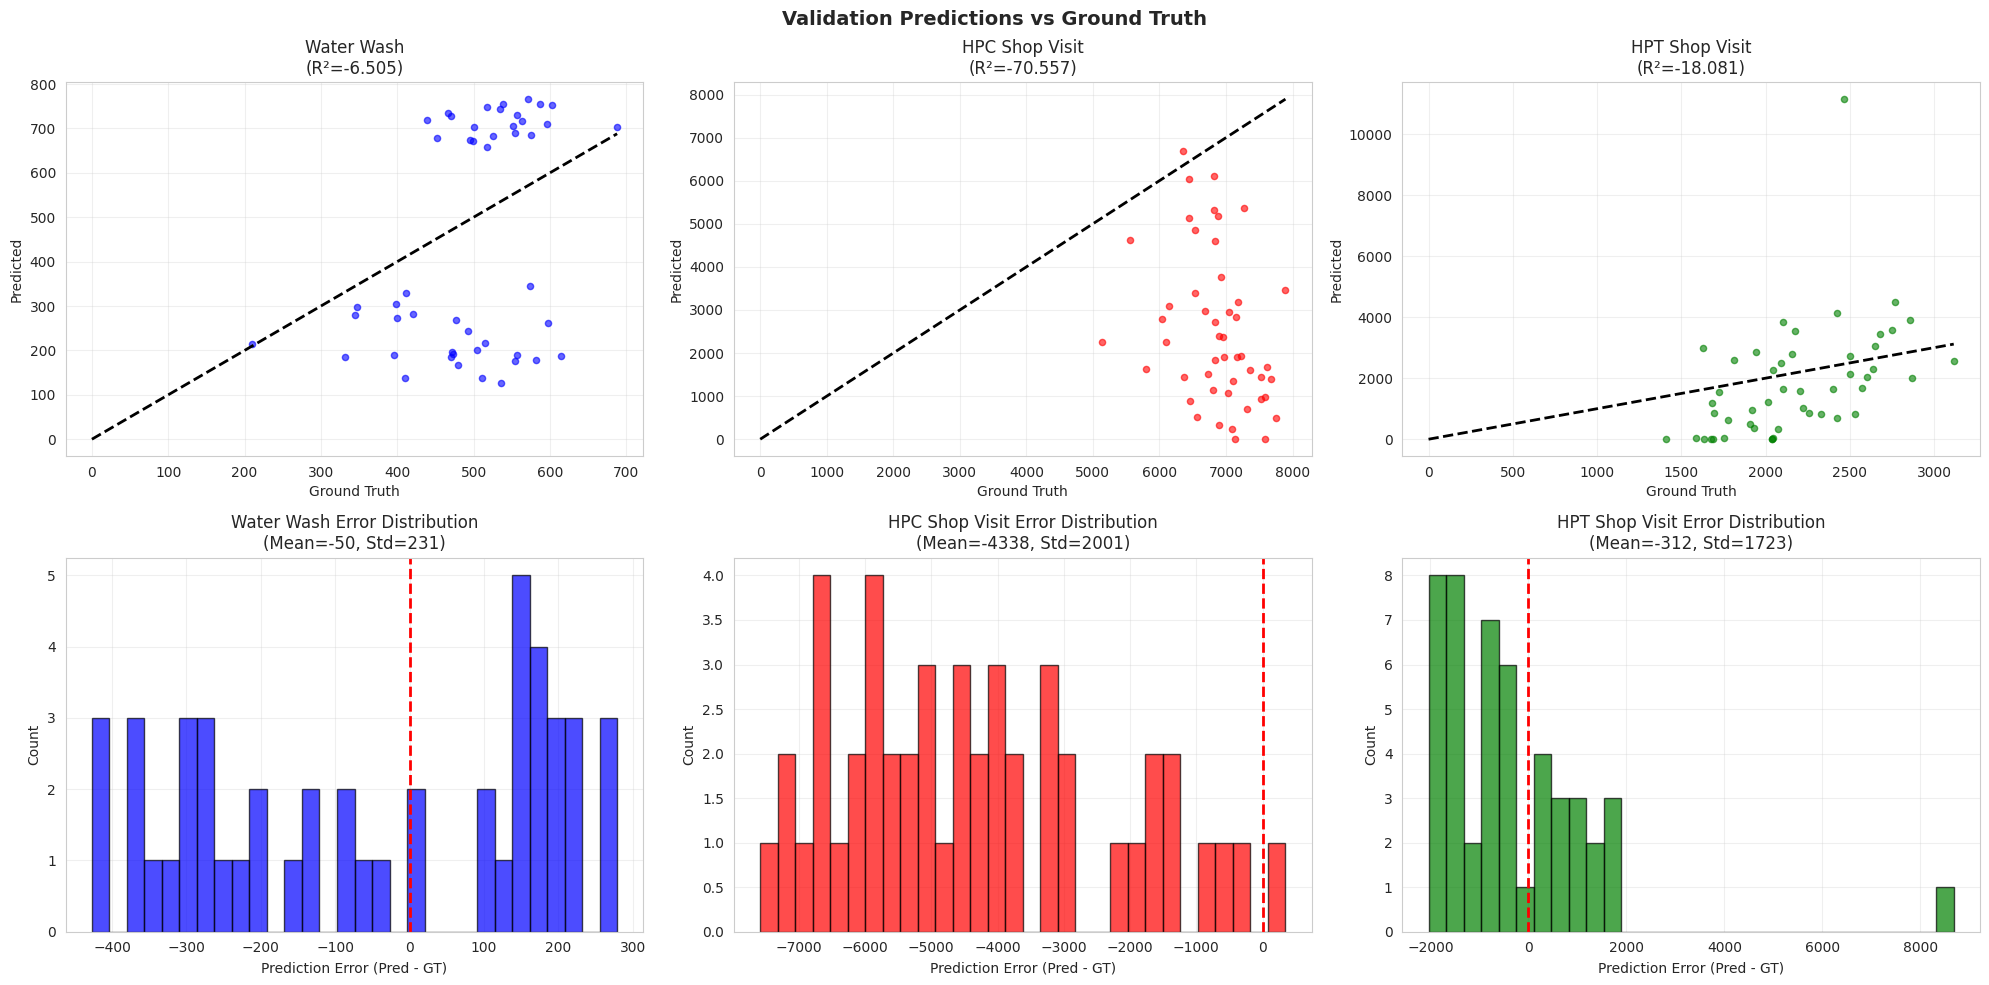

In [ ]:
# Figure 13-14: Validation predictions visualization
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

targets_names = [
    ('Cycles_to_WW', 'Water Wash', 'blue'),
    ('Cycles_to_HPC_SV', 'HPC Shop Visit', 'red'),
    ('Cycles_to_HPT_SV', 'HPT Shop Visit', 'green')
]

for i, (target, name, color) in enumerate(targets_names):
    gt = val_compare[f'{target}_gt'].values
    pred = val_compare[f'{target}_pred'].values
    
    # Scatter plot
    axes[0, i].scatter(gt, pred, s=20, alpha=0.6, color=color)
    axes[0, i].plot([0, gt.max()], [0, gt.max()], 'k--', linewidth=2)
    axes[0, i].set_xlabel('Ground Truth')
    axes[0, i].set_ylabel('Predicted')
    r2 = r2_score(gt, pred)
    axes[0, i].set_title(f'{name}\n(R²={r2:.3f})')
    axes[0, i].grid(True, alpha=0.3)
    
    # Error distribution
    errors = pred - gt
    axes[1, i].hist(errors, bins=30, color=color, alpha=0.7, edgecolor='black')
    axes[1, i].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[1, i].set_xlabel('Prediction Error (Pred - GT)')
    axes[1, i].set_ylabel('Count')
    axes[1, i].set_title(f'{name} Error Distribution\n(Mean={errors.mean():.0f}, Std={errors.std():.0f})')
    axes[1, i].grid(True, alpha=0.3)

plt.suptitle('Validation Predictions vs Ground Truth', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

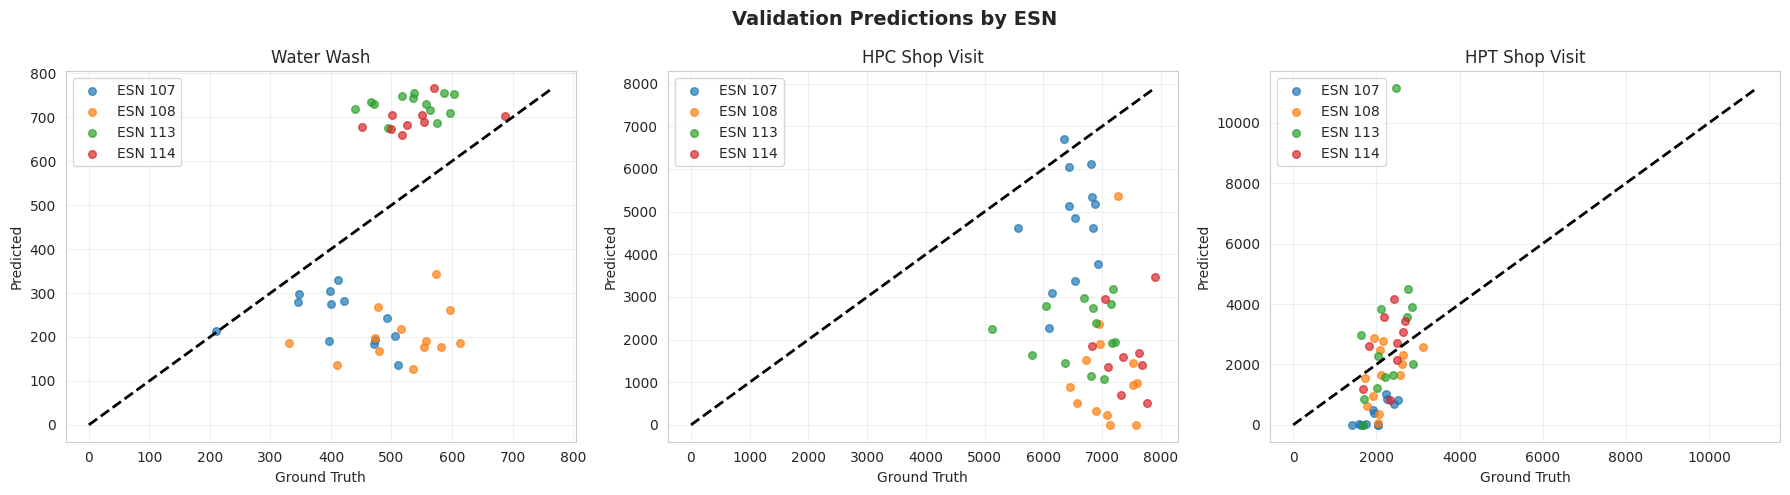

In [ ]:
# Figure: Per-ESN validation predictions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Add ESN info to validation predictions
val_esn_map = {}
for fname, df_f in val_data.items():
    val_esn_map[fname] = df_f['ESN'].iloc[0]

val_compare['ESN'] = val_compare['file'].map(val_esn_map)

for i, (target, name, color) in enumerate(targets_names):
    for esn in sorted(val_compare.ESN.unique()):
        sub = val_compare[val_compare.ESN == esn]
        axes[i].scatter(sub[f'{target}_gt'], sub[f'{target}_pred'], 
                       s=30, alpha=0.7, label=f'ESN {esn}')
    
    vmax = max(val_compare[f'{target}_gt'].max(), val_compare[f'{target}_pred'].max())
    axes[i].plot([0, vmax], [0, vmax], 'k--', linewidth=2)
    axes[i].set_xlabel('Ground Truth')
    axes[i].set_ylabel('Predicted')
    axes[i].set_title(f'{name}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Validation Predictions by ESN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Generate submission.csv
# Format: file, Cycles_to_WW, Cycles_to_HPC_SV, Cycles_to_HPT_SV

submission = df_test_preds[['file', 'Cycles_to_WW', 'Cycles_to_HPC_SV', 'Cycles_to_HPT_SV']].copy()
submission = submission.sort_values('file', key=lambda x: x.str.extract(r'(\d+)')[0].astype(int))
submission = submission.reset_index(drop=True)

# Save
submission_path = os.path.join(BASE_DIR, 'submission.csv')
submission.to_csv(submission_path, index=False)
print(f'Submission saved to: {submission_path}')
print(f'Shape: {submission.shape}')
print(f'\nFirst 10 rows:')
submission.head(10)

Submission saved to: /home/began/srcs/begbaj/phm-america-2025/submission.csv
Shape: (52, 4)

First 10 rows:


,file,Cycles_to_WW,Cycles_to_HPC_SV,Cycles_to_HPT_SV
0,test_0,121,119,2051
1,test_1,641,1772,477
2,test_2,628,1642,2795
3,test_3,449,5129,401
4,test_4,666,3403,3051
5,test_5,495,4629,156
6,test_6,631,1411,525
7,test_7,151,7549,0
8,test_8,274,6907,213
9,test_9,186,1789,1352


In [ ]:
# Also save validation submission
val_submission = df_val_preds[['file', 'Cycles_to_WW', 'Cycles_to_HPC_SV', 'Cycles_to_HPT_SV']].copy()
val_submission = val_submission.sort_values('file', key=lambda x: x.str.extract(r'(\d+)')[0].astype(int))
val_submission = val_submission.reset_index(drop=True)

val_submission_path = os.path.join(BASE_DIR, 'submission_validation.csv')
# Don't overwrite ground truth - save as separate file
val_pred_path = os.path.join(BASE_DIR, 'submission_validation_predicted.csv')
val_submission.to_csv(val_pred_path, index=False)
print(f'Validation predictions saved to: {val_pred_path}')

Validation predictions saved to: /home/began/srcs/begbaj/phm-america-2025/submission_validation_predicted.csv


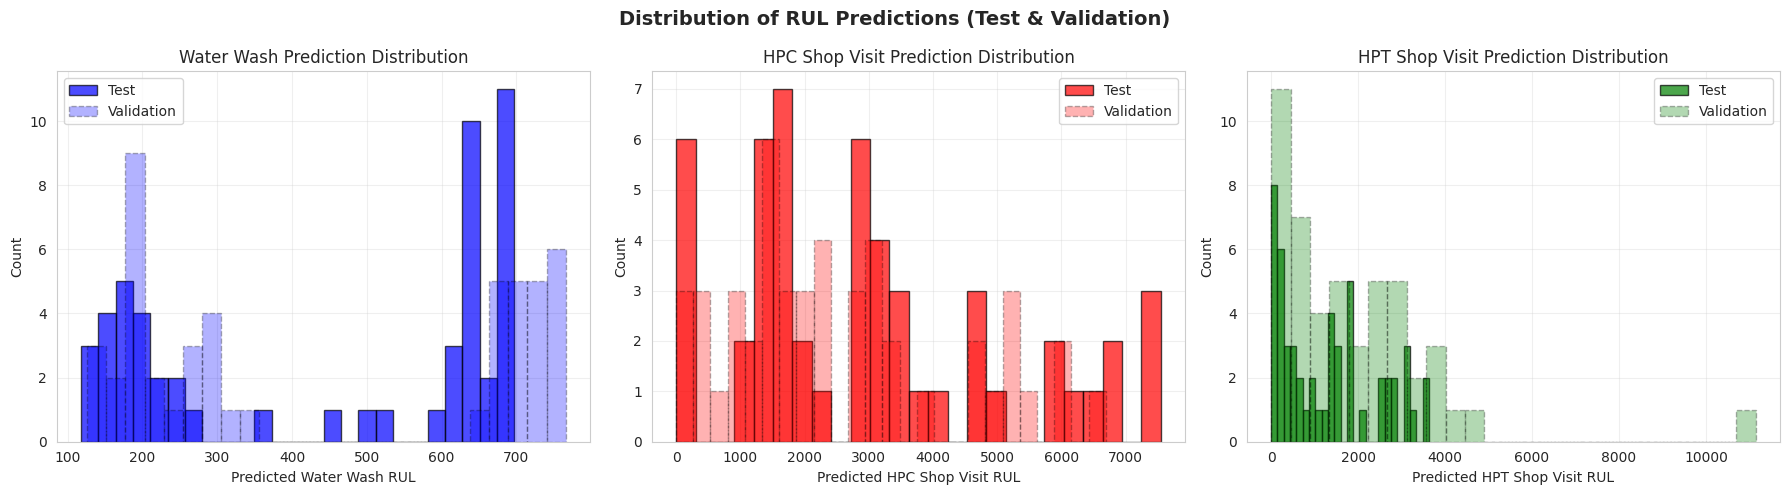

In [ ]:
# Final Summary plot: Distribution of predictions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (target, name, color) in enumerate(targets_names):
    axes[i].hist(submission[target], bins=25, color=color, alpha=0.7, edgecolor='black', label='Test')
    axes[i].hist(val_submission[target], bins=25, color=color, alpha=0.3, edgecolor='black', 
                linestyle='--', label='Validation')
    axes[i].set_xlabel(f'Predicted {name} RUL')
    axes[i].set_ylabel('Count')
    axes[i].set_title(f'{name} Prediction Distribution')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Distribution of RUL Predictions (Test & Validation)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Final summary
print('=' * 70)
print('IMPLEMENTATION SUMMARY (with Hyperparameter Grid Search)')
print('=' * 70)
print(f'\n1. PREPROCESSING:')
print(f'   - Missing data: interpolated per ESN per snapshot')
print(f'   - Outliers: {outlier_count} values removed via 1.5×IQR rule')
print(f'\n2. VIRTUAL SENSORS:')
print(f'   - P25: RMSE={p25_rmse:.4f}, R²={p25_r2:.4f}')
print(f'   - T5: RMSE={t5_rmse:.4f}, R²={t5_r2:.4f}')
print(f'\n3. FEATURE ENGINEERING:')
print(f'   - {len(selected_features)} selected features after variance thresholding')
print(f'   - {len(eng_features)} domain-informed engineered features')
print(f'\n4. HEALTH INDICATORS:')
print(f'   - HPC HI: {len(hpc_weights)} features weighted')
print(f'   - HPT HI: {len(hpt_weights)} features weighted')
print(f'\n5. MODELS (Grid Search Optimized):')
print(f'   - HPT SV: {best_hpt_name}')
print(f'     Params: {results_hpt[best_hpt_name].get("best_params", "N/A")}')
print(f'   - WW: LSTM (h={best_ww_config["hidden_size"]}, L={best_ww_config["num_layers"]}, '
      f'd={best_ww_config["dropout"]}, lr={best_ww_config["lr"]}, seq={SEQ_LEN})')
print(f'   - HPC SV: LSTM (h={best_hpc_config["hidden_size"]}, L={best_hpc_config["num_layers"]}, '
      f'd={best_hpc_config["dropout"]}, lr={best_hpc_config["lr"]}, seq={SEQ_LEN_HPC})')
print(f'\n6. PREDICTIONS:')
print(f'   - Test: {len(submission)} files')
print(f'   - Validation: {len(val_submission)} files')
print(f'\n7. OUTPUT:')
print(f'   - submission.csv saved to {submission_path}')
print('=' * 70)

IMPLEMENTATION SUMMARY

1. PREPROCESSING:
   - Missing data: interpolated per ESN per snapshot
   - Outliers: 27589 values removed via 1.5×IQR rule

2. VIRTUAL SENSORS:
   - P25: RMSE=0.3768, R²=0.9985
   - T5: RMSE=8.4183, R²=0.9932

3. FEATURE ENGINEERING:
   - 98 selected features after variance thresholding
   - 15 domain-informed engineered features

4. HEALTH INDICATORS:
   - HPC HI: 19 features weighted
   - HPT HI: 28 features weighted

5. MODELS:
   - HPT SV: ANN (MLP) with GradientBoosting architecture
   - WW: LSTM (hidden=128, layers=2, seq_len=1500)
   - HPC SV: LSTM (hidden=128, layers=2, seq_len=1500)

6. PREDICTIONS:
   - Test: 52 files
   - Validation: 48 files

7. OUTPUT:
   - submission.csv saved to /home/began/srcs/begbaj/phm-america-2025/submission.csv
